# Comprehensive Dataset Analysis for Thesis

This notebook provides a thorough analysis of a temporal graph dataset. It is designed to generate high-quality figures, tables, and metrics suitable for direct inclusion in a LaTeX thesis.

The analysis covers:
1.  **Dataset Overview**: Basic statistics and dataset dimensions.
2.  **Feature Analysis**: Distribution, correlation, missing values, and temporal trends of node features.
3.  **Graph Structure Analysis**: Properties of the adjacency matrices, including sparsity, degree distribution, connectivity, and centrality measures.
4.  **Temporal Evolution**: How graph and feature properties change over time.
5.  **Combined Feature and Graph Analysis**: Exploring the relationship between node features and their position within the graph.

## 1. Setup and Data Loading

First, we import the necessary libraries and define the paths to our train, validation, and test datasets. We then load them using the `MarketAnalyzer` class from our utility script.

In [1]:
# Import required libraries
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.stats import entropy

# Add the project root to the Python path to allow importing dataset_analyzer
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from dataset_analyzer import MarketAnalyzer

# Set plot style for thesis-quality figures
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)
FIGURE_OUTPUT_PATH = Path('./thesis_figures')
FIGURE_OUTPUT_PATH.mkdir(exist_ok=True)

def save_figure(filename):
    """Helper function to save figures in a consistent format."""
    plt.savefig(FIGURE_OUTPUT_PATH / f"{filename}.pdf", format='pdf', bbox_inches='tight')
    plt.savefig(FIGURE_OUTPUT_PATH / f"{filename}.png", format='png', bbox_inches='tight', dpi=300)
    print(f"Figure saved to {FIGURE_OUTPUT_PATH / f'{filename}.pdf'}")

In [2]:
# --- Configuration ---
MARKET = 'NYSE'
NORMALIZATION = 'zscore'
WINDOW_SIZE = 22
adj_minmax = True
threshold = .2
# Define dataset paths
base_path = project_root / 'data' / 'datasets' / 'graph'
train_path = base_path / f"{MARKET}_Train_2016-05-01_2017-06-30_{WINDOW_SIZE}_{NORMALIZATION}"
val_path = base_path / f"{MARKET}_Validation_2017-07-01_2017-12-31_{WINDOW_SIZE}_{NORMALIZATION}"
test_path = base_path / f"{MARKET}_Test_2018-01-01_2019-12-31_{WINDOW_SIZE}_{NORMALIZATION}"

# Load datasets using the MarketAnalyzer

train_analyzer = MarketAnalyzer(train_path, adj_minmax=adj_minmax, threshold=threshold)
val_analyzer = MarketAnalyzer(val_path, train_path=train_path, adj_minmax=adj_minmax, threshold=threshold)
test_analyzer = MarketAnalyzer(test_path, train_path=train_path, adj_minmax=adj_minmax, threshold=threshold)

analyzers = {'Train': train_analyzer, 'Validation': val_analyzer, 'Test': test_analyzer}

print("Datasets loaded successfully.")

|             Dataset Information             |
| Market Name:         NYSE                    |
| Time Period:         Train                   |
| Start Date:          2016-05-01              |
| End Date:            2017-06-30              |
| Window Size:         22                      |
| Normalizer:          zscore                  |
| Number of Features:  5                       |
| Number of Nodes:     1171                    |
| Number of Snapshots: 219                     |
Folder analysis_results already exists at /extra/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/NYSE_Train_2016-05-01_2017-06-30_22_zscore
|             Dataset Information             |
| Market Name:         NYSE                    |
| Time Period:         Validation              |
| Start Date:          2017-07-01              |
| End Date:            2017-12-31              |
| Window Size:         22                      |
| Normalizer:          zscore                  |
| Number of Feature

### 1.1. Dataset Overview

We begin by generating a summary table that provides an overview of the key dimensions of each dataset split.

In [3]:
train_analyzer.num_nodes

1171

In [4]:
overview_data = []
for name, analyzer in analyzers.items():
    info = {
        'Dataset': name,
        'Num Nodes': analyzer.num_nodes,
        'Num Features': analyzer.num_features,
        'Num Snapshots': analyzer.num_snapshots
    }
    overview_data.append(info)

overview_df = pd.DataFrame(overview_data).set_index('Dataset')

print("--- Dataset Overview ---")
display(overview_df)

print("\n--- LaTeX Table ---")
print(overview_df.to_latex(caption='Overview of dataset dimensions.', label='tab:dataset_overview'))

--- Dataset Overview ---


,Num Nodes,Num Features,Num Snapshots
Dataset,,,
Train,1171,5,219
Validation,1171,5,101
Test,1171,5,469



--- LaTeX Table ---
\begin{table}
\caption{Overview of dataset dimensions.}
\label{tab:dataset_overview}
\begin{tabular}{lrrr}
\toprule
 & Num Nodes & Num Features & Num Snapshots \\
Dataset &  &  &  \\
\midrule
Train & 1171 & 5 & 219 \\
Validation & 1171 & 5 & 101 \\
Test & 1171 & 5 & 469 \\
\bottomrule
\end{tabular}
\end{table}




### 1.2. Cross-Dataset Comparison

Before diving deeper, it's crucial to verify that the train, validation, and test sets are statistically similar. Significant differences could indicate issues with the data splitting process and lead to a model that generalizes poorly. Here, we compare key distributions across the three dataset splits.


Figure saved to thesis_figures/cross_dataset_degree_distribution.pdf


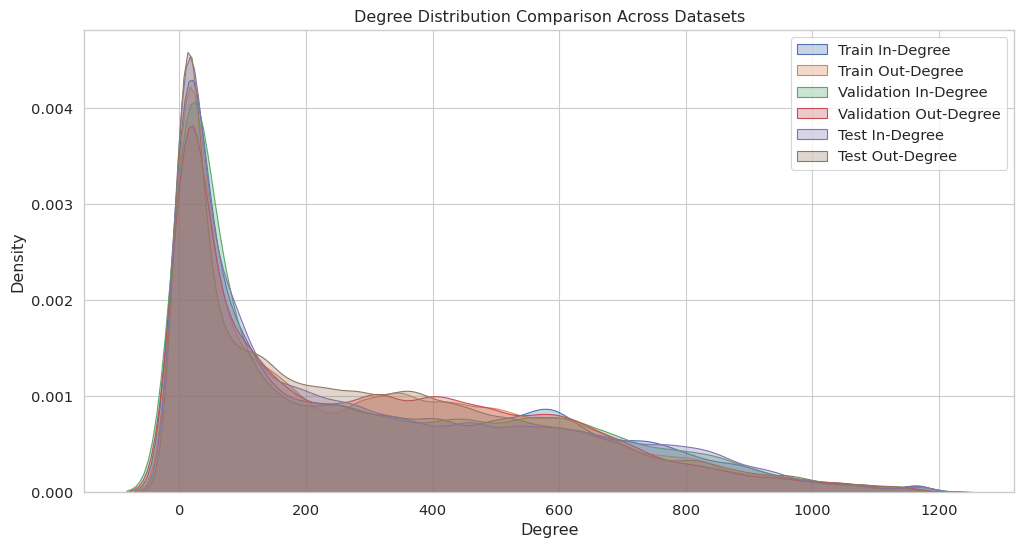

In [5]:

# --- 1. Compare Degree Distribution ---
plt.figure(figsize=(12, 6))
for name, analyzer in analyzers.items():
    in_degrees, out_degrees, _, _ = analyzer.get_degree_dist()
    sns.kdeplot(in_degrees, label=f'{name} In-Degree', fill=True, alpha=0.3)
    sns.kdeplot(out_degrees, label=f'{name} Out-Degree', fill=True, alpha=0.3)
plt.title('Degree Distribution Comparison Across Datasets')
plt.xlabel('Degree')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
save_figure('cross_dataset_degree_distribution')
plt.show()

Figure saved to thesis_figures/cross_dataset_feature_distribution.pdf


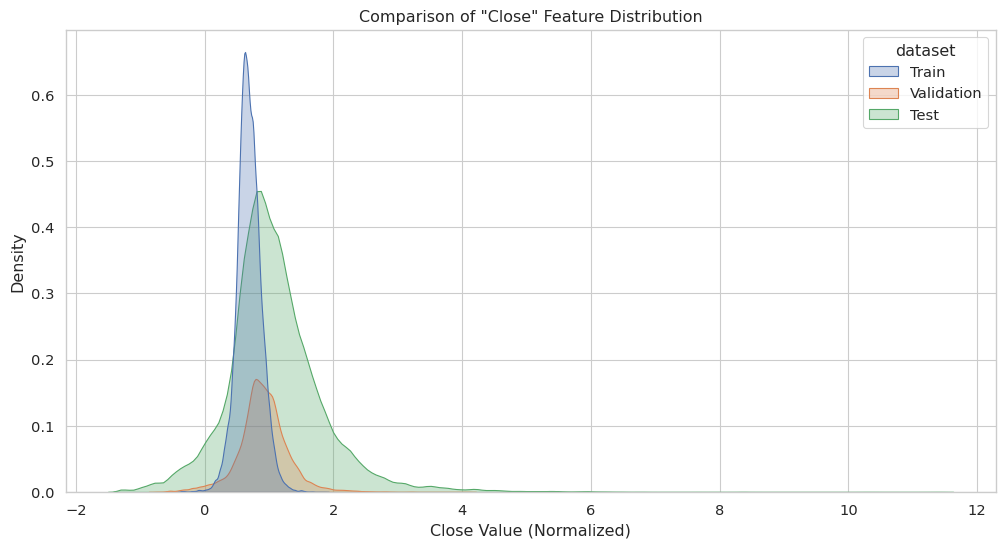

In [6]:
# --- 2. Compare a Key Node Feature Distribution (e.g., 'Close') ---
feature_data = []
for name, analyzer in analyzers.items():
    df = analyzer.analyze_node_features()
    df['dataset'] = name
    feature_data.append(df)

full_feature_df = pd.concat(feature_data)
plt.figure(figsize=(12, 6))
sns.kdeplot(data=full_feature_df, x='Close', hue='dataset', fill=True, alpha=0.3)
plt.title('Comparison of "Close" Feature Distribution')
plt.xlabel('Close Value (Normalized)')
plt.ylabel('Density')
plt.grid(True)
save_figure('cross_dataset_feature_distribution')
plt.show()

Figure saved to thesis_figures/cross_dataset_feature_distribution_all.pdf


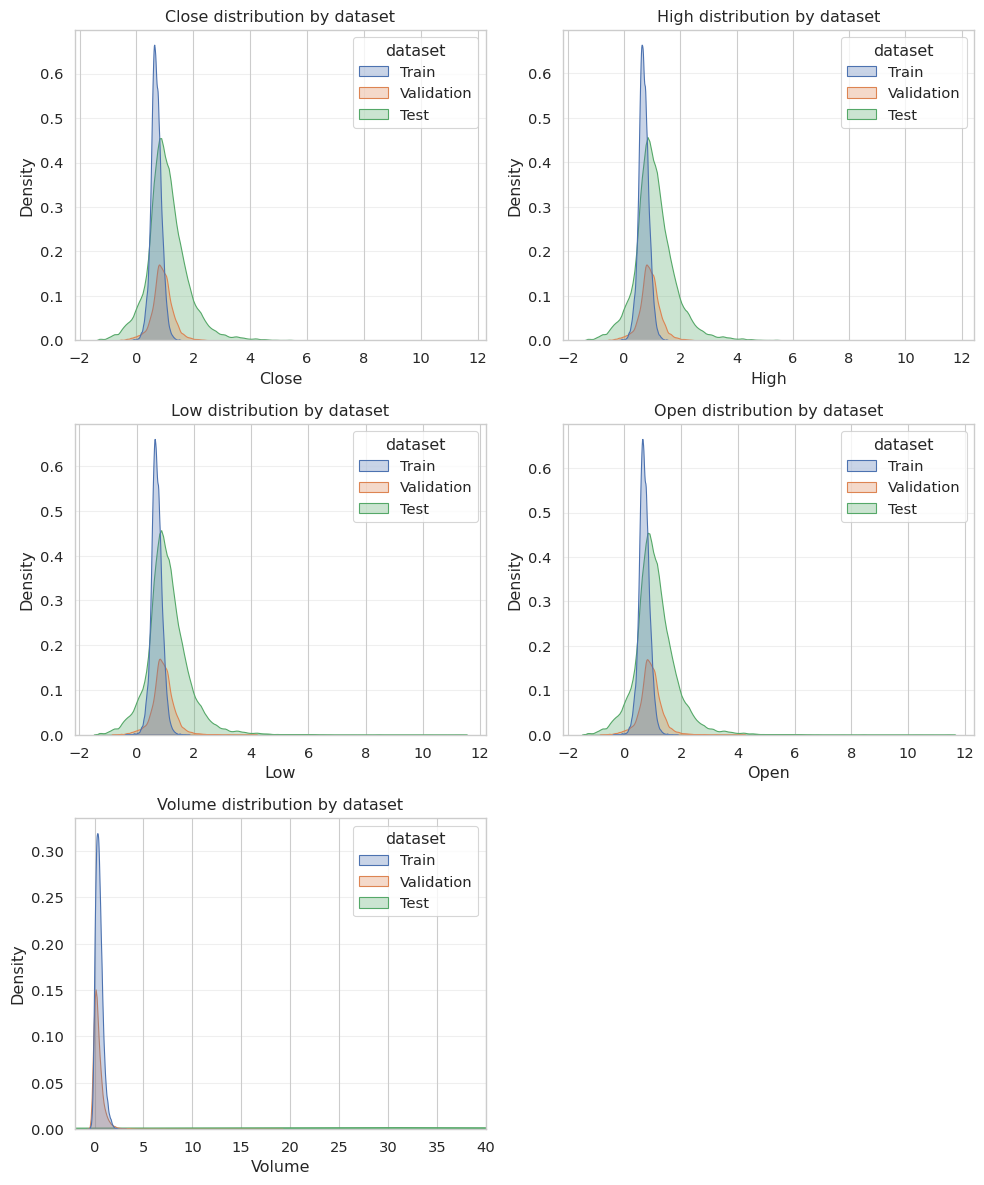

In [7]:
# --- 2b. Compare All Feature Distributions Across Datasets ---
# Build/ensure a combined features dataframe with a 'dataset' column
if 'full_feature_df' not in locals():
    feature_data = []
    for name, analyzer in analyzers.items():
        df = analyzer.analyze_node_features()
        df['dataset'] = name
        feature_data.append(df)
    full_feature_df = pd.concat(feature_data, ignore_index=True)

# Select only features that are present and numeric
candidate_features = [f for f in train_analyzer.features if f in full_feature_df.columns]
candidate_features = [f for f in ['Close', 'High', 'Low', 'Open', 'Volume']]
numeric_features = []
for f in candidate_features:
    try:
        if pd.api.types.is_numeric_dtype(full_feature_df[f]):
            numeric_features.append(f)
    except Exception:
        pass

if len(numeric_features) == 0:
    print('No numeric features found to plot in cross-dataset comparison.')
else:
    n = len(numeric_features)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)

    for idx, feature in enumerate(numeric_features):
        r, c = divmod(idx, ncols)
        ax = axes[r][c]
        try:
            # Drop NaNs for the feature to avoid seaborn issues
            tmp = full_feature_df[[feature, 'dataset']].dropna()
            if tmp[feature].nunique() <= 1:
                ax.text(0.5, 0.5, f'{feature}: constant', ha='center', va='center')
                ax.set_axis_off()
                continue
            if feature == 'Volume':
                sns.kdeplot(data=tmp, x=feature, hue='dataset', fill=True, alpha=0.3, ax=ax)
                ax.set_xlim(-2, 40)  # limit Volume range
            else:
                sns.kdeplot(data=tmp, x=feature, hue='dataset', fill=True, alpha=0.3, ax=ax)
            ax.set_title(f'{feature} distribution by dataset')
            ax.set_xlabel(feature)
            ax.set_ylabel('Density')
            ax.grid(True, axis='y', alpha=0.3)
        except Exception as e:
            ax.text(0.5, 0.5, f'Error plotting {feature}:\n{e}', ha='center', va='center')
            ax.set_axis_off()

    # Turn off any leftover axes
    total_axes = nrows * ncols
    for j in range(n, total_axes):
        r, c = divmod(j, ncols)
        axes[r][c].set_axis_off()

    plt.tight_layout()
    save_figure('cross_dataset_feature_distribution_all')
    plt.show()

In [8]:
# --- 2c. Feature Means and Variances by Dataset ---
# Build the combined features dataframe if missing
if 'full_feature_df' not in locals():
    feature_data = []
    for name, analyzer in analyzers.items():
        df = analyzer.analyze_node_features()
        df['dataset'] = name
        feature_data.append(df)
    full_feature_df = pd.concat(feature_data, ignore_index=True)

# Determine numeric features from the analyzer's feature list
all_numeric_features = []
for f in getattr(train_analyzer, 'features', []):
    if f in full_feature_df.columns:
        try:
            if pd.api.types.is_numeric_dtype(full_feature_df[f]):
                all_numeric_features.append(f)
        except Exception:
            pass

if len(all_numeric_features) == 0:
    print('No numeric features found to summarize (mean/variance).')
else:
    # Compute mean and variance per dataset for the selected features
    stats_df = full_feature_df.groupby('dataset')[all_numeric_features].agg(['mean', 'var'])

    # Optional: order datasets if all are present
    desired_order = [name for name in ['Train', 'Validation', 'Test'] if name in stats_df.index]
    if desired_order:
        stats_df = stats_df.loc[desired_order]

    # Round for readability
    stats_df_rounded = stats_df.round(4)

    print('--- Feature Means and Variances by Dataset ---')
    display(stats_df_rounded)

    # Also provide a LaTeX-friendly version
    try:
        print('\n--- LaTeX Table ---')
        print(stats_df_rounded.to_latex(caption='Feature means and variances per dataset.',
                                        label='tab:feature_means_vars',
                                        escape=True))
    except Exception as e:
        print(f'Could not export LaTeX table: {e}')

--- Feature Means and Variances by Dataset ---


Close            High             Low            Open          \
              mean     var    mean     var    mean     var    mean     var   
dataset                                                                      
Train       0.6838  0.0367  0.6838  0.0364  0.6840  0.0369  0.6840  0.0367   
Validation  0.9063  0.1562  0.9047  0.1555  0.9081  0.1566  0.9063  0.1561   
Test        1.0847  0.5995  1.0878  0.6005  1.0832  0.5990  1.0860  0.6005   

            Volume               
              mean          var  
dataset                          
Train       0.4416      0.14510  
Validation  0.3699      0.36680  
Test        5.0730  36616.15625


--- LaTeX Table ---
\begin{table}
\caption{Feature means and variances per dataset.}
\label{tab:feature_means_vars}
\begin{tabular}{lrrrrrrrrrr}
\toprule
 & \multicolumn{2}{r}{Close} & \multicolumn{2}{r}{High} & \multicolumn{2}{r}{Low} & \multicolumn{2}{r}{Open} & \multicolumn{2}{r}{Volume} \\
 & mean & var & mean & var & mean & var & mean & var & mean & var \\
dataset &  &  &  &  &  &  &  &  &  &  \\
\midrule
Train & 0.683800 & 0.036700 & 0.683800 & 0.036400 & 0.684000 & 0.036900 & 0.684000 & 0.036700 & 0.441600 & 0.145100 \\
Validation & 0.906300 & 0.156200 & 0.904700 & 0.155500 & 0.908100 & 0.156600 & 0.906300 & 0.156100 & 0.369900 & 0.366800 \\
Test & 1.084700 & 0.599500 & 1.087800 & 0.600500 & 1.083200 & 0.599000 & 1.086000 & 0.600500 & 5.073000 & 36616.156250 \\
\bottomrule
\end{tabular}
\end{table}



In [12]:
feature_data[2][['ticker','Volume']].groupby('ticker').mean().sort_values(by='Volume', ascending=False).head(10)


,Volume
ticker,
PYS,5292.013184
CBI,16.302635
PCG,7.193752
VET,4.381324
BEP,3.694511
ABR,3.596618
BRT,3.347835
SPB,3.022587
GE,2.969283


Figure saved to thesis_figures/cross_dataset_class_distribution.pdf


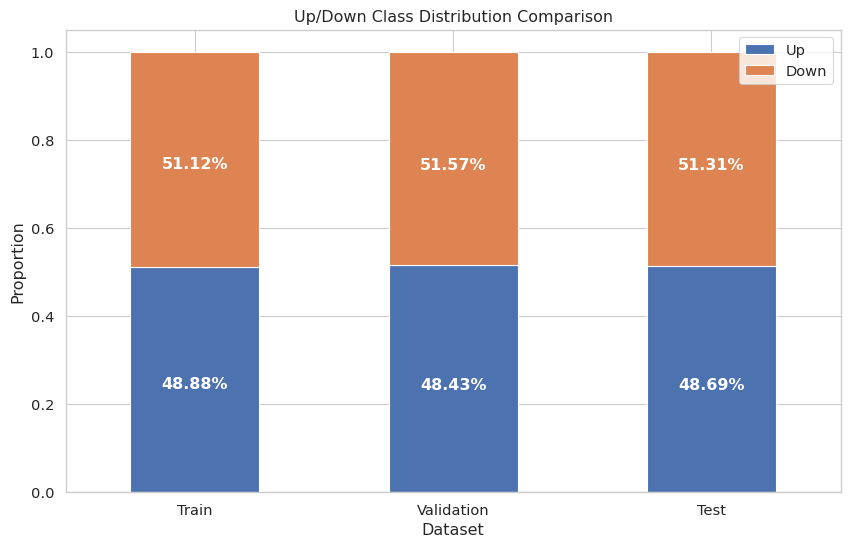

In [8]:
# --- 3. Compare Up/Down Class Distribution ---
class_ratios = {name: analyzer.get_class_dist() for name, analyzer in analyzers.items()}
class_df = pd.DataFrame(class_ratios).T.rename(columns={0: 'Down', 1: 'Up'})

class_df.plot(kind='bar', stacked=True, figsize=(10, 6), rot=0)
plt.title('Up/Down Class Distribution Comparison')
plt.ylabel('Proportion')
plt.xlabel('Dataset')
for index, row in enumerate(class_df.itertuples()):
    if row.Down > 0:
        plt.text(index, row.Down / 2, f'{row.Down:.2%}', ha='center', va='center', color='white', weight='bold')
    if row.Up > 0:
        plt.text(index, row.Down + (row.Up / 2), f'{row.Up:.2%}', ha='center', va='center', color='white', weight='bold')
save_figure('cross_dataset_class_distribution')
plt.show()

Figure saved to thesis_figures/cross_dataset_connectivity.pdf


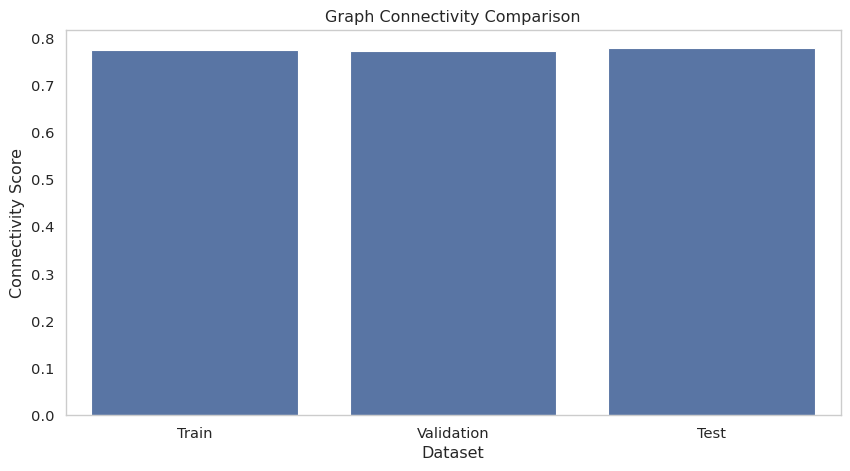

In [9]:
# --- 4. Compare Graph Connectivity ---
connectivity_scores = {name: analyzer.get_connectivity() for name, analyzer in analyzers.items()}
connectivity_df = pd.DataFrame.from_dict(connectivity_scores, orient='index', columns=['Connectivity'])

plt.figure(figsize=(10, 5))
sns.barplot(x=connectivity_df.index, y=connectivity_df['Connectivity'])
plt.title('Graph Connectivity Comparison')
plt.ylabel('Connectivity Score')
plt.xlabel('Dataset')
plt.grid(axis='y')
save_figure('cross_dataset_connectivity')
plt.show()  

In [10]:
connectivity_df

,Connectivity
Train,0.775329
Validation,0.773649
Test,0.778439


## 2. Feature Analysis

In this section, we conduct a deep dive into the node features. We analyze their statistical properties, distributions, correlations, and temporal behavior.

### 2.1. Feature Statistics and Missing Values

We compute descriptive statistics for each feature in the training set and check for missing values across all datasets.

In [11]:
# We focus on the training set for deep feature analysis
features_df = train_analyzer.analyze_node_features()

# --- Feature Statistics ---
feature_stats = features_df[train_analyzer.features].describe()
print("--- Feature Statistics (Training Set) ---")
display(feature_stats)
print("\n--- LaTeX Table ---")
print(feature_stats.to_latex(caption='Descriptive statistics for node features in the training set.', label='tab:feature_stats', float_format="%.3f"))

# --- Missing Values Check ---
missing_values_data = []
for name, analyzer in analyzers.items():
    df = analyzer.analyze_node_features()
    missing_pct = df.isnull().sum() / len(df) * 100
    missing_pct.name = name
    missing_values_data.append(missing_pct)

missing_df = pd.concat(missing_values_data, axis=1)
print("\n--- Missing Value Percentages (%s) ---")
display(missing_df)

--- Feature Statistics (Training Set) ---


,Close,High,Low,Open,Volume
count,256449.000000,256449.000000,256449.000000,256449.000000,256449.000000
mean,0.683789,0.683781,0.684008,0.684013,0.441603
std,0.191507,0.190806,0.192015,0.191616,0.380910
min,-0.377504,-0.377876,-0.378200,-0.380427,-0.650100
25%,0.567065,0.567889,0.566376,0.567001,0.169529
50%,0.674627,0.674717,0.674971,0.674819,0.388195
75%,0.800074,0.799249,0.800791,0.800218,0.652546
max,1.882572,1.843889,1.807249,1.843962,3.147901



--- LaTeX Table ---
\begin{table}
\caption{Descriptive statistics for node features in the training set.}
\label{tab:feature_stats}
\begin{tabular}{lrrrrr}
\toprule
 & Close & High & Low & Open & Volume \\
\midrule
count & 256449.000 & 256449.000 & 256449.000 & 256449.000 & 256449.000 \\
mean & 0.684 & 0.684 & 0.684 & 0.684 & 0.442 \\
std & 0.192 & 0.191 & 0.192 & 0.192 & 0.381 \\
min & -0.378 & -0.378 & -0.378 & -0.380 & -0.650 \\
25% & 0.567 & 0.568 & 0.566 & 0.567 & 0.170 \\
50% & 0.675 & 0.675 & 0.675 & 0.675 & 0.388 \\
75% & 0.800 & 0.799 & 0.801 & 0.800 & 0.653 \\
max & 1.883 & 1.844 & 1.807 & 1.844 & 3.148 \\
\bottomrule
\end{tabular}
\end{table}


--- Missing Value Percentages (%s) ---


,Train,Validation,Test
Close,0.0,0.0,0.0
High,0.0,0.0,0.0
Low,0.0,0.0,0.0
Open,0.0,0.0,0.0
Volume,0.0,0.0,0.0
node_idx,0.0,0.0,0.0
ticker,0.0,0.0,0.0
snapshot_idx,0.0,0.0,0.0


### 2.2. Feature Distributions

Visualizing the distribution of each feature helps us understand their underlying patterns.

Figure saved to thesis_figures/feature_distributions_dynamic.pdf


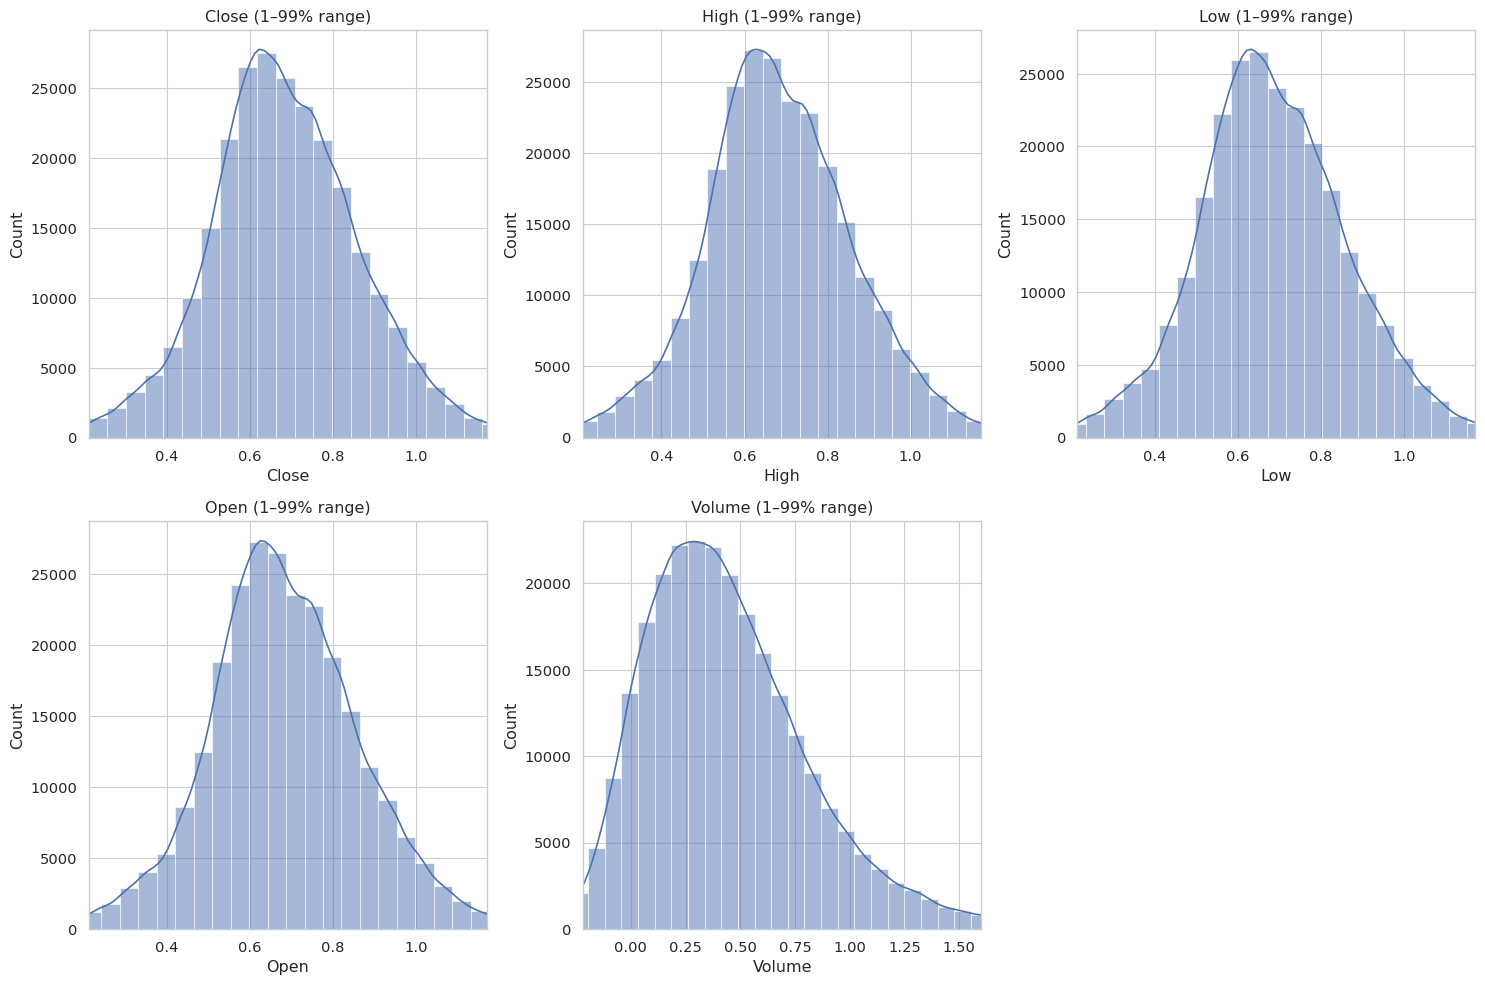

In [12]:
plt.figure(figsize=(15, 10))

for i, feature in enumerate(train_analyzer.features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(features_df[feature], kde=True, bins=50)
    
    # Compute percentile range
    q_low, q_high = features_df[feature].quantile([0.01, 0.99])
    
    # Apply x-limits dynamically
    plt.xlim(q_low, q_high)
    
    plt.title(f'{feature} (1–99% range)')
    
plt.tight_layout()
save_figure('feature_distributions_dynamic')
plt.show()


### 2.3. Feature Correlation

A correlation matrix reveals linear relationships between features.

In [13]:
# --- Centralize adjacency matrices for all splits (Section 3 optimization) ---
adjacency_matrices = {name: analyzer.get_snapshots_adjacency_matrix() for name, analyzer in analyzers.items()}
train_adjs = adjacency_matrices.get('Train')
val_adjs = adjacency_matrices.get('Validation')
test_adjs = adjacency_matrices.get('Test')

Adjacency matrix shape: (1171, 1171)
Adjacency matrix shape: (1171, 1171)
Adjacency matrix shape: (1171, 1171)


Figure saved to thesis_figures/feature_correlation_matrix.pdf


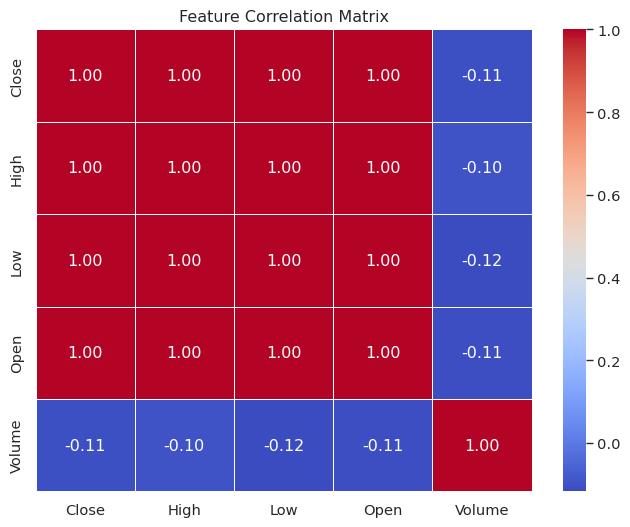

In [14]:
correlation_matrix = features_df[train_analyzer.features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Feature Correlation Matrix')
save_figure('feature_correlation_matrix')
plt.show()

### 2.4. Feature Entropy

Feature entropy measures the predictability of a feature. Higher entropy implies less predictability.

---

## 2.5. Comprehensive Graph Metrics Summary

This section computes key graph-level metrics averaged across **all snapshots** for each dataset split, providing a robust statistical summary with mean and standard deviation values.

In [15]:
def compute_comprehensive_metrics(analyzer, adjacency_matrices, subsample_snapshots=None):
    """
    Compute comprehensive graph metrics for DIRECTED graphs.
    
    Args:
        analyzer: MarketAnalyzer instance
        adjacency_matrices: List of adjacency matrices
        subsample_snapshots: If specified, randomly sample this many snapshots instead of using all.
                           Set to None to use all snapshots.
    
    Returns a dictionary with mean and std for each metric.
    """
    num_snapshots = analyzer.num_snapshots
    
    if subsample_snapshots is not None and subsample_snapshots < num_snapshots:
        snapshot_indices = np.random.choice(num_snapshots, size=subsample_snapshots, replace=False)
        print(f"  → Subsampling {subsample_snapshots} snapshots out of {num_snapshots}")
    else:
        snapshot_indices = range(num_snapshots)
    
    # Initialize lists
    connectivity_list = []
    sparsity_list = []
    num_weakly_cc_list = []
    num_strongly_cc_list = []
    reciprocity_list = []
    clustering_list = []
    homophily_list = []
    
    for idx, i in enumerate(snapshot_indices):
        if idx % 10 == 0:
            print(f"  → Processing snapshot {idx+1}/{len(snapshot_indices)}...", end='\r')
        
        snapshot_info = analyzer.get_snapshot_info(i)
        connectivity_list.append(snapshot_info['connectivity'])
        
        num_nodes = snapshot_info['num_nodes']
        num_edges = snapshot_info['num_edges']
        possible_edges = num_nodes * (num_nodes - 1)  # Directed: N*(N-1)
        sparsity = 1.0 - (num_edges / possible_edges) if possible_edges > 0 else 0.0
        sparsity_list.append(sparsity)
        
        homophily = analyzer.get_homophily_score(i)
        homophily_list.append(homophily)
        
        # Create DIRECTED graph
        adj = adjacency_matrices[i]
        from scipy.sparse import csr_matrix
        adj_sparse = csr_matrix(adj)
        G_directed = nx.from_scipy_sparse_array(adj_sparse, create_using=nx.DiGraph)
        
        # Directed-specific metrics
        num_weakly_cc = nx.number_weakly_connected_components(G_directed)
        num_strongly_cc = nx.number_strongly_connected_components(G_directed)
        num_weakly_cc_list.append(num_weakly_cc)
        num_strongly_cc_list.append(num_strongly_cc)
        
        # Reciprocity: fraction of edges that have a reverse edge
        try:
            reciprocity = nx.reciprocity(G_directed)
        except:
            reciprocity = 0.0
        reciprocity_list.append(reciprocity)
        
        # Clustering coefficient (treats directed as undirected for triangle counting)
        try:
            clustering = nx.average_clustering(G_directed)
        except:
            clustering = 0.0
        clustering_list.append(clustering)
    
    print()
    
    metrics = {
        'Connectivity': {
            'mean': np.mean(connectivity_list),
            'std': np.std(connectivity_list)
        },
        'Sparsity': {
            'mean': np.mean(sparsity_list),
            'std': np.std(sparsity_list)
        },
        'Weakly Connected Components': {
            'mean': np.mean(num_weakly_cc_list),
            'std': np.std(num_weakly_cc_list)
        },
        'Strongly Connected Components': {
            'mean': np.mean(num_strongly_cc_list),
            'std': np.std(num_strongly_cc_list)
        },
        'Reciprocity': {
            'mean': np.mean(reciprocity_list),
            'std': np.std(reciprocity_list)
        },
        'Clustering Coefficient': {
            'mean': np.mean(clustering_list),
            'std': np.std(clustering_list)
        },
        'Homophily': {
            'mean': np.mean(homophily_list),
            'std': np.std(homophily_list)
        }
    }
    
    return metrics

# Compute metrics
SUBSAMPLE_SNAPSHOTS = 5  # Change to None to use all snapshots

print("Computing comprehensive metrics across snapshots...")
print(f"Settings: subsample={SUBSAMPLE_SNAPSHOTS}\n")

comprehensive_metrics = {}
for name, analyzer in analyzers.items():
    adj_mats = adjacency_matrices.get(name)
    if adj_mats is None or len(adj_mats) == 0:
        print(f"⚠ Skipping {name}: no adjacency matrices available")
        continue
    
    print(f"Processing {name}... ({analyzer.num_snapshots} snapshots)")
    metrics = compute_comprehensive_metrics(
        analyzer, 
        adj_mats,
        subsample_snapshots=SUBSAMPLE_SNAPSHOTS
    )
    comprehensive_metrics[name] = metrics

print("\n✓ Metrics computation complete!")

Computing comprehensive metrics across snapshots...
Settings: subsample=5

Processing Train... (219 snapshots)
  → Subsampling 5 snapshots out of 219
  → Processing snapshot 1/5...
Processing Validation... (101 snapshots)
  → Subsampling 5 snapshots out of 101
  → Processing snapshot 1/5...
Processing Test... (469 snapshots)
  → Subsampling 5 snapshots out of 469
  → Processing snapshot 1/5...

✓ Metrics computation complete!


In [16]:
# Create a summary DataFrame for display
summary_data = []
for name, metrics in comprehensive_metrics.items():
    for metric_name, values in metrics.items():
        summary_data.append({
            'Dataset': name,
            'Metric': metric_name,
            'Mean': values['mean'],
            'Std': values['std']
        })

summary_df = pd.DataFrame(summary_data)

# Pivot for better visualization
summary_pivot = summary_df.pivot(index='Metric', columns='Dataset', values='Mean')
std_pivot = summary_df.pivot(index='Metric', columns='Dataset', values='Std')

print("\n" + "="*80)
print("COMPREHENSIVE GRAPH METRICS SUMMARY (Mean across all snapshots)")
print("="*80)
display(summary_pivot.round(3))

print("\n" + "="*80)
print("STANDARD DEVIATION OF METRICS (across all snapshots)")
print("="*80)
display(std_pivot.round(4))


COMPREHENSIVE GRAPH METRICS SUMMARY (Mean across all snapshots)


Dataset,Test,Train,Validation
Metric,,,
Clustering Coefficient,0.800,0.796,0.796
Connectivity,0.777,0.773,0.773
Homophily,0.546,0.553,0.547
Reciprocity,0.710,0.704,0.704
Sparsity,0.223,0.227,0.227
Strongly Connected Components,3.200,3.200,3.400
Weakly Connected Components,1.000,1.000,1.000



STANDARD DEVIATION OF METRICS (across all snapshots)


Dataset,Test,Train,Validation
Metric,,,
Clustering Coefficient,0.0019,0.0038,0.0034
Connectivity,0.0017,0.0036,0.0032
Homophily,0.0535,0.0609,0.0535
Reciprocity,0.0029,0.0061,0.0054
Sparsity,0.0017,0.0036,0.0032
Strongly Connected Components,0.4000,0.4000,0.8000
Weakly Connected Components,0.0000,0.0000,0.0000


In [17]:
def generate_latex_table(comprehensive_metrics, market_name):
    """
    Generate a LaTeX table from comprehensive metrics.
    
    Returns the LaTeX code as a string.
    """
    # Define the order of datasets (columns)
    dataset_order = ['Train', 'Validation', 'Test']
    available_datasets = [d for d in dataset_order if d in comprehensive_metrics]
    
    # Define metric order (rows)
    metric_order = comprehensive_metrics[available_datasets[0]].keys()
    
    # Start building the LaTeX table
    latex = []
    latex.append(r"\begin{table}[H]")
    latex.append(r"    \centering")
    
    # Create column specification
    col_spec = "l|" + "c" * len(available_datasets)
    latex.append(f"    \\begin{{tabular}}{{{col_spec}}}")
    latex.append(r"        \toprule")
    
    # Header row
    header = r"        \textbf{Metric}"
    for dataset in available_datasets:
        header += f" & \\textbf{{{dataset}}}"
    header += r" \\"
    latex.append(header)
    latex.append(r"        \midrule")
    
    # Data rows
    for metric_name in metric_order:
        if metric_name not in comprehensive_metrics.get(available_datasets[0], {}):
            continue
        
        # Format metric name for LaTeX
        latex_metric_name = metric_name
        if metric_name == "Num CC":
            latex_metric_name = r"\#CC\footnotemark[1]"
        
        row = f"        {latex_metric_name:24s}"
        
        for dataset in available_datasets:
            mean_val = comprehensive_metrics[dataset][metric_name]['mean']
            std_val = comprehensive_metrics[dataset][metric_name]['std']
            
            # Format value (3 decimal places for mean)
            if metric_name == "Num CC":
                # Integer value for number of connected components
                row += f" & {mean_val:.0f}"
            else:
                row += f" & {mean_val:.3f}"
        
        row += r" \\"
        latex.append(row)
    
    latex.append(r"        \bottomrule")
    latex.append(r"    \end{tabular}")
    latex.append(f"    \\caption{{Summary of Graph-Level Metrics for {market_name} Dataset (Mean across all snapshots)}}")
    latex.append(f"    \\label{{tab:{market_name.lower()}_graph_metrics}}")
    latex.append(r"\end{table}")
    
    # Add footnote explanation
    latex.append("")
    latex.append(r"% Footnote: \footnotemark[1] Number of Connected Components")
    
    return "\n".join(latex)


# Generate and display LaTeX table
latex_table = generate_latex_table(comprehensive_metrics, MARKET)

print("\n" + "="*80)
print("LATEX TABLE CODE (Copy this to your thesis)")
print("="*80)
print(latex_table)
print("="*80)

# Also save to file
latex_output_path = FIGURE_OUTPUT_PATH / f"{MARKET}_metrics_table.tex"
with open(latex_output_path, 'w') as f:
    f.write(latex_table)
print(f"\n✓ LaTeX table saved to: {latex_output_path}")


LATEX TABLE CODE (Copy this to your thesis)
\begin{table}[H]
    \centering
    \begin{tabular}{l|ccc}
        \toprule
        \textbf{Metric} & \textbf{Train} & \textbf{Validation} & \textbf{Test} \\
        \midrule
        Connectivity             & 0.773 & 0.773 & 0.777 \\
        Sparsity                 & 0.227 & 0.227 & 0.223 \\
        Weakly Connected Components & 1.000 & 1.000 & 1.000 \\
        Strongly Connected Components & 3.200 & 3.400 & 3.200 \\
        Reciprocity              & 0.704 & 0.704 & 0.710 \\
        Clustering Coefficient   & 0.796 & 0.796 & 0.800 \\
        Homophily                & 0.553 & 0.547 & 0.546 \\
        \bottomrule
    \end{tabular}
    \caption{Summary of Graph-Level Metrics for NYSE Dataset (Mean across all snapshots)}
    \label{tab:nyse_graph_metrics}
\end{table}

% Footnote: \footnotemark[1] Number of Connected Components

✓ LaTeX table saved to: thesis_figures/NYSE_metrics_table.tex


In [18]:
# OPTIONAL: Generate table with Mean ± Std format
def generate_latex_table_with_std(comprehensive_metrics, market_name):
    """
    Generate a LaTeX table with Mean ± Std format.
    """
    dataset_order = ['Train', 'Validation', 'Test']
    available_datasets = [d for d in dataset_order if d in comprehensive_metrics]
    
    metric_order = comprehensive_metrics[available_datasets[0]].keys()

    
    latex = []
    latex.append(r"\begin{table}[h]")
    latex.append(r"    \centering")
    latex.append(r"    \small")  # Make font smaller to fit std values
    
    col_spec = "l|" + "c" * len(available_datasets)
    latex.append(f"    \\begin{{tabular}}{{{col_spec}}}")
    latex.append(r"        \toprule")
    
    header = r"        \textbf{Metric}"
    for dataset in available_datasets:
        header += f" & \\textbf{{{dataset}}}"
    header += r" \\"
    latex.append(header)
    latex.append(r"        \midrule")
    
    for metric_name in metric_order:
        if metric_name not in comprehensive_metrics.get(available_datasets[0], {}):
            continue
        
        latex_metric_name = metric_name
        if metric_name == "Num CC":
            latex_metric_name = r"\#CC\footnotemark[1]"
        
        row = f"        {latex_metric_name:24s}"
        
        for dataset in available_datasets:
            mean_val = comprehensive_metrics[dataset][metric_name]['mean']
            std_val = comprehensive_metrics[dataset][metric_name]['std']
            
            if metric_name == "Num CC":
                row += f" & ${mean_val:.0f} \\pm {std_val:.2f}$"
            else:
                row += f" & ${mean_val:.3f} \\pm {std_val:.4f}$"
        
        row += r" \\"
        latex.append(row)
    
    latex.append(r"        \bottomrule")
    latex.append(r"    \end{tabular}")
    latex.append(f"    \\caption{{Summary of Graph-Level Metrics for {market_name} Dataset (Mean $\\pm$ Std across all snapshots)}}")
    latex.append(f"    \\label{{tab:{market_name.lower()}_graph_metrics_std}}")
    latex.append(r"\end{table}")
    latex.append("")
    latex.append(r"% Footnote: \footnotemark[1] Number of Connected Components")
    
    return "\n".join(latex)


# Generate table with std
latex_table_with_std = generate_latex_table_with_std(comprehensive_metrics, MARKET)

print("\n" + "="*80)
print("LATEX TABLE WITH STANDARD DEVIATION")
print("="*80)
print(latex_table_with_std)
print("="*80)

# Save to file
latex_std_output_path = FIGURE_OUTPUT_PATH / f"{MARKET}_metrics_table_with_std.tex"
with open(latex_std_output_path, 'w') as f:
    f.write(latex_table_with_std)
print(f"\n✓ LaTeX table (with std) saved to: {latex_std_output_path}")


LATEX TABLE WITH STANDARD DEVIATION
\begin{table}[h]
    \centering
    \small
    \begin{tabular}{l|ccc}
        \toprule
        \textbf{Metric} & \textbf{Train} & \textbf{Validation} & \textbf{Test} \\
        \midrule
        Connectivity             & $0.773 \pm 0.0036$ & $0.773 \pm 0.0032$ & $0.777 \pm 0.0017$ \\
        Sparsity                 & $0.227 \pm 0.0036$ & $0.227 \pm 0.0032$ & $0.223 \pm 0.0017$ \\
        Weakly Connected Components & $1.000 \pm 0.0000$ & $1.000 \pm 0.0000$ & $1.000 \pm 0.0000$ \\
        Strongly Connected Components & $3.200 \pm 0.4000$ & $3.400 \pm 0.8000$ & $3.200 \pm 0.4000$ \\
        Reciprocity              & $0.704 \pm 0.0061$ & $0.704 \pm 0.0054$ & $0.710 \pm 0.0029$ \\
        Clustering Coefficient   & $0.796 \pm 0.0038$ & $0.796 \pm 0.0034$ & $0.800 \pm 0.0019$ \\
        Homophily                & $0.553 \pm 0.0609$ & $0.547 \pm 0.0535$ & $0.546 \pm 0.0535$ \\
        \bottomrule
    \end{tabular}
    \caption{Summary of Graph-Level Me

Figure saved to thesis_figures/feature_entropy.pdf


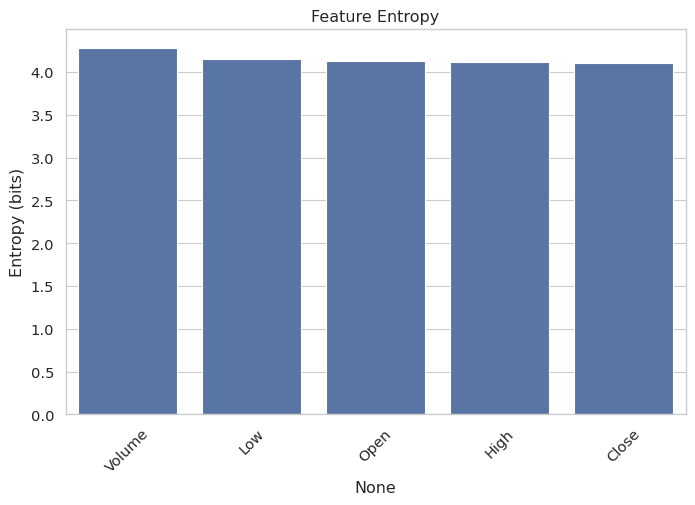

--- Feature Entropy ---


,Entropy
Volume,4.283300
Low,4.156007
Open,4.126438
High,4.120763
Close,4.103533


In [19]:
def calculate_entropy(series, bins=50):
    """Calculates the entropy of a continuous series."""
    counts = np.histogram(series, bins=bins)[0]
    return entropy(counts, base=2)

feature_entropy = {feat: calculate_entropy(features_df[feat]) for feat in train_analyzer.features}
entropy_series = pd.Series(feature_entropy).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=entropy_series.index, y=entropy_series.values)
plt.title('Feature Entropy')
plt.ylabel('Entropy (bits)')
plt.xticks(rotation=45)
save_figure('feature_entropy')
plt.show()

print("--- Feature Entropy ---")
display(entropy_series.to_frame('Entropy'))

## 3. Graph Structure Analysis

This section focuses on the properties of the graph itself, derived from the adjacency matrices.

### 3.1. Adjacency Matrix Visualization and Sparsity

We visualize the adjacency matrix of the first snapshot and compute sparsity statistics.

Figure saved to thesis_figures/adjacency_matrix_first_snapshot.pdf


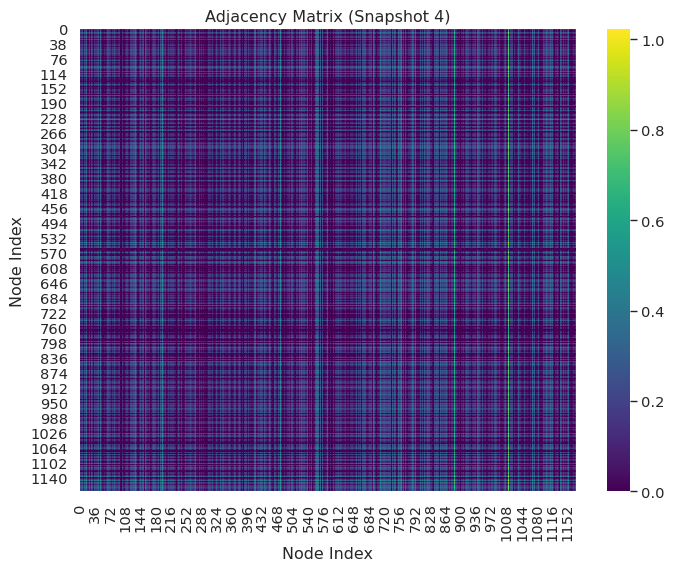

In [20]:
# Reuse the centralized adjacency matrices defined above
snapshot_index = 4  # Adjust as needed for inspection
# --- Visualize Selected Adjacency Matrix ---
plt.figure(figsize=(8, 6))
sns.heatmap(train_adjs[snapshot_index], cmap='viridis')
plt.title(f'Adjacency Matrix (Snapshot {snapshot_index})')
plt.xlabel('Node Index')
plt.ylabel('Node Index')
save_figure('adjacency_matrix_first_snapshot')
plt.show()

In [21]:
# --- Sparsity and Edge Weight Analysis ---
sparsity_data = []
for name, adjs in adjacency_matrices.items():
    if adjs is None or len(adjs) == 0:
        continue
    sparsity = 1.0 - np.mean([np.count_nonzero(adj) / adj.size for adj in adjs])
    sparsity_data.append({'Dataset': name, 'Sparsity': sparsity, 'Connectivity': analyzers[name].get_connectivity()})

sparsity_df = pd.DataFrame(sparsity_data).set_index('Dataset')
print("--- Graph Sparsity ---")
display(sparsity_df)

--- Graph Sparsity ---


,Sparsity,Connectivity
Dataset,,
Train,0.225334,0.775329
Validation,0.227012,0.773649
Test,0.222225,0.778439


Random snapshot selected: 38
Figure saved to thesis_figures/edge_weight_distribution_snapshot.pdf


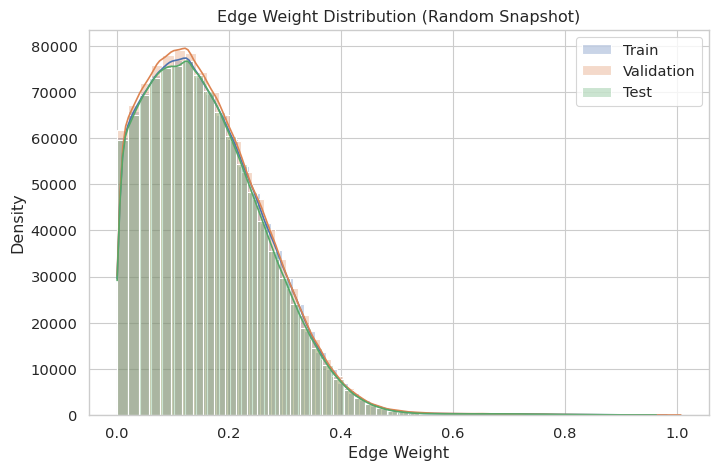

In [22]:
import random
available_lengths = [len(adjs) for adjs in [train_adjs, val_adjs, test_adjs] if adjs is not None]
if not available_lengths:
    raise ValueError('No adjacency matrices available to sample from.')
snapshot_idx = random.randint(0, min(available_lengths) - 1)
print(f"Random snapshot selected: {snapshot_idx}")

edge_weights_sets = {
    'Train': train_adjs,
    'Validation': val_adjs,
    'Test': test_adjs
}

plt.figure(figsize=(8, 5))
for label, adjs in edge_weights_sets.items():
    if adjs is None:
        continue
    weights = adjs[snapshot_idx][adjs[snapshot_idx] > 0].flatten()
    if len(weights) == 0:
        continue
    sns.histplot(weights, bins=50, kde=True, alpha=0.3, label=label)

plt.legend()
plt.title('Edge Weight Distribution (Random Snapshot)')
plt.xlabel('Edge Weight')
plt.ylabel('Density')
save_figure('edge_weight_distribution_snapshot')
plt.show()

# --- 3.2. Degree Distribution

The degree of a node is its number of connections. For a directed graph, we analyze both in-degree (incoming edges) and out-degree (outgoing edges).

Figure saved to thesis_figures/unweighted_degree_distribution.pdf


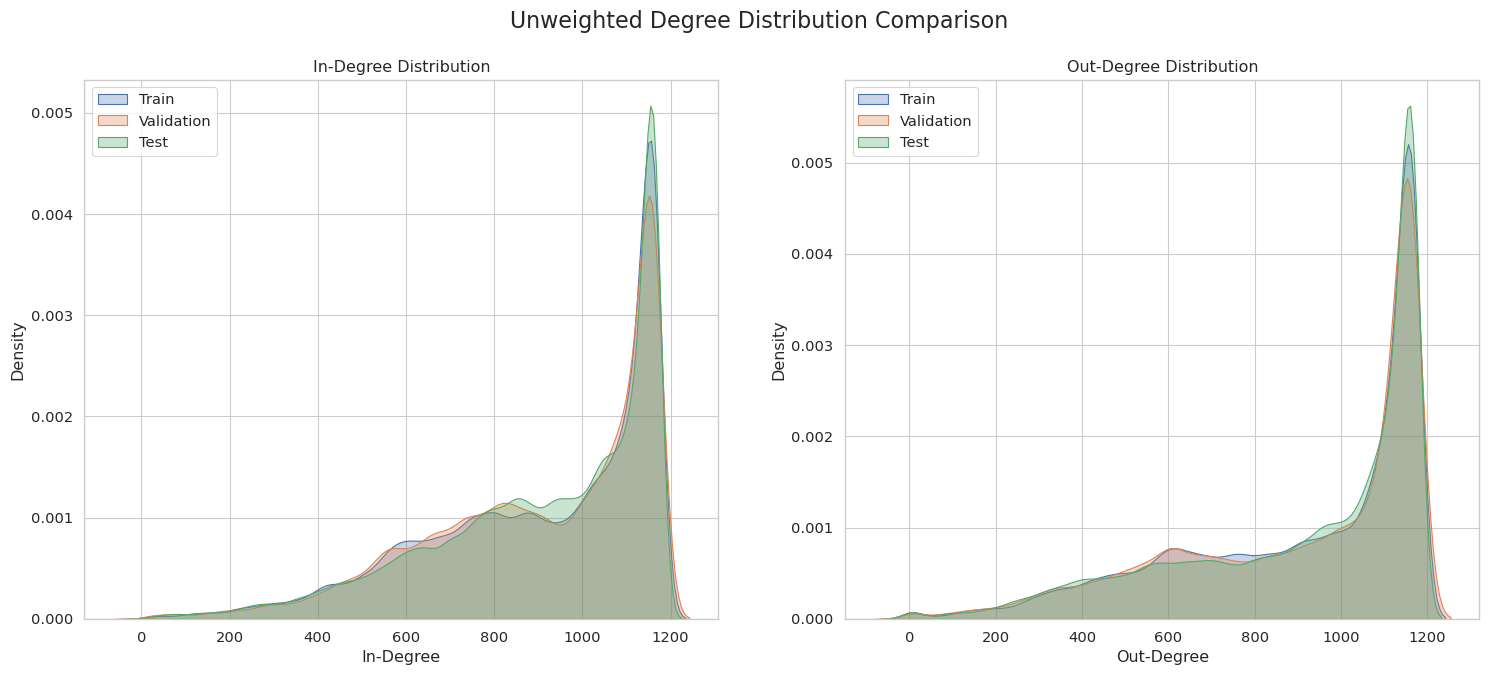

Figure saved to thesis_figures/weighted_degree_distribution.pdf


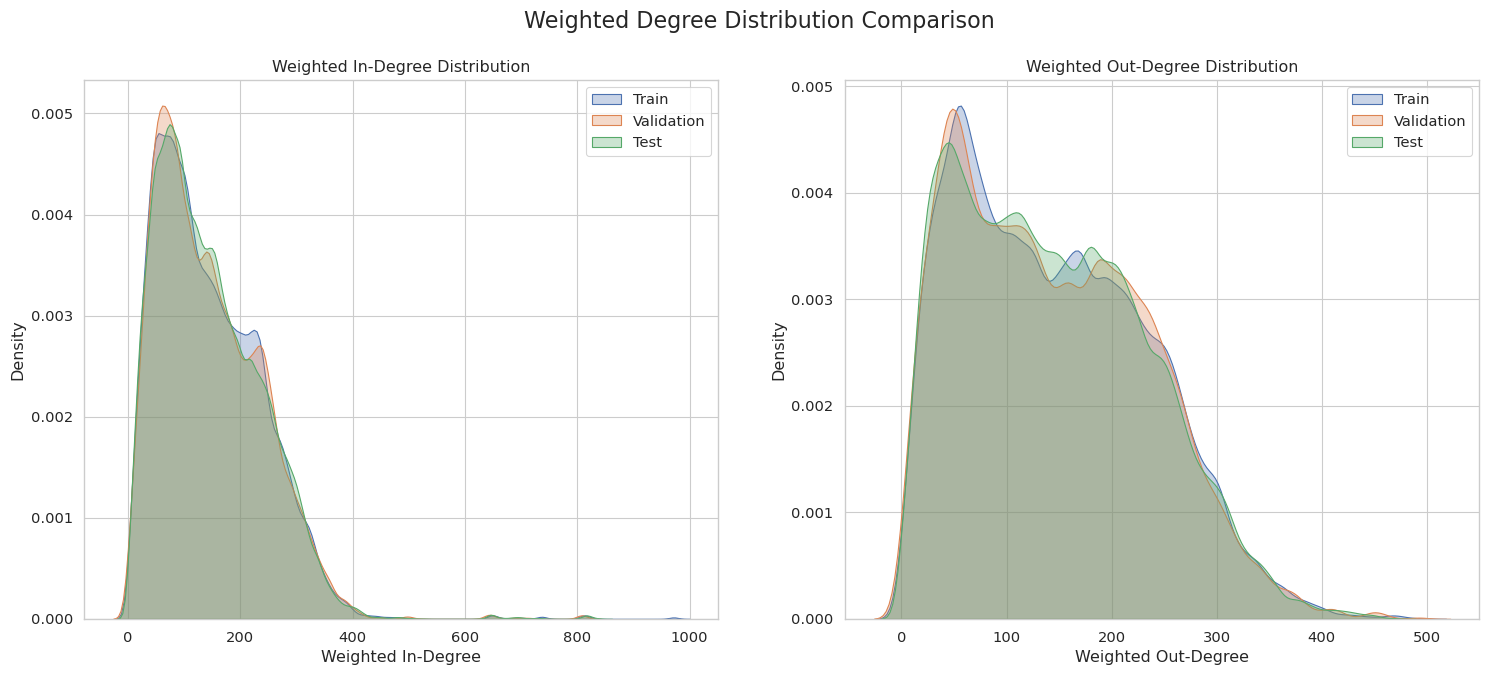

In [23]:
# --- Unweighted (Absolute) Degree Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Unweighted Degree Distribution Comparison', fontsize=16)

# In-Degree
for name, analyzer in analyzers.items():
    in_degrees, out_degrees, _, _ = analyzer.get_degree_dist()
    sns.kdeplot(in_degrees, ax=axes[0], label=name, fill=True, alpha=0.3)
axes[0].set_title('In-Degree Distribution')
axes[0].set_xlabel('In-Degree')
axes[0].set_ylabel('Density')
axes[0].legend()

# Out-Degree
for name, analyzer in analyzers.items():
    _, out_degrees, _, _ = analyzer.get_degree_dist()
    sns.kdeplot(out_degrees, ax=axes[1], label=name, fill=True, alpha=0.3)
axes[1].set_title('Out-Degree Distribution')
axes[1].set_xlabel('Out-Degree')
axes[1].legend()

save_figure('unweighted_degree_distribution')
plt.show()

# --- Weighted Degree Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Weighted Degree Distribution Comparison', fontsize=16)

# Weighted In-Degree
for name, analyzer in analyzers.items():
    _, _, weighted_in_degrees, _ = analyzer.get_degree_dist()
    sns.kdeplot(weighted_in_degrees, ax=axes[0], label=name, fill=True, alpha=0.3)
axes[0].set_title('Weighted In-Degree Distribution')
axes[0].set_xlabel('Weighted In-Degree')
axes[0].set_ylabel('Density')
axes[0].legend()

# Weighted Out-Degree
for name, analyzer in analyzers.items():
    _, _, _, weighted_out_degrees = analyzer.get_degree_dist()
    sns.kdeplot(weighted_out_degrees, ax=axes[1], label=name, fill=True, alpha=0.3)
axes[1].set_title('Weighted Out-Degree Distribution')
axes[1].set_xlabel('Weighted Out-Degree')
axes[1].legend()

save_figure('weighted_degree_distribution')
plt.show()


### 3.3. Connectivity and Clustering

We analyze graph connectivity (number of components) and the clustering coefficient, which measures the tendency of nodes to form triangles.

### 3.4. Centrality Measures

Centrality measures identify the most important nodes in the graph. We compute Degree, Eigenvector, and Betweenness centrality.

--- Top 5 Nodes by Centrality Measures ---

--- Top 5 by Degree Centrality ---


GPC    1.772650
MLM    1.772650
MSM    1.770940
AMG    1.770085
DPZ    1.769231
Name: Degree, dtype: float64


--- Top 5 by Eigenvector Centrality ---


TCAP    0.209224
JBR     0.186373
PYS     0.161699
CBI     0.098933
GYC     0.098351
Name: Eigenvector, dtype: float64


--- Top 5 by Betweenness Centrality ---


EGHT    0.029551
DCM     0.022920
KS      0.021169
TTF     0.019783
SEM     0.014771
Name: Betweenness, dtype: float64

Figure saved to thesis_figures/centrality_distributions.pdf


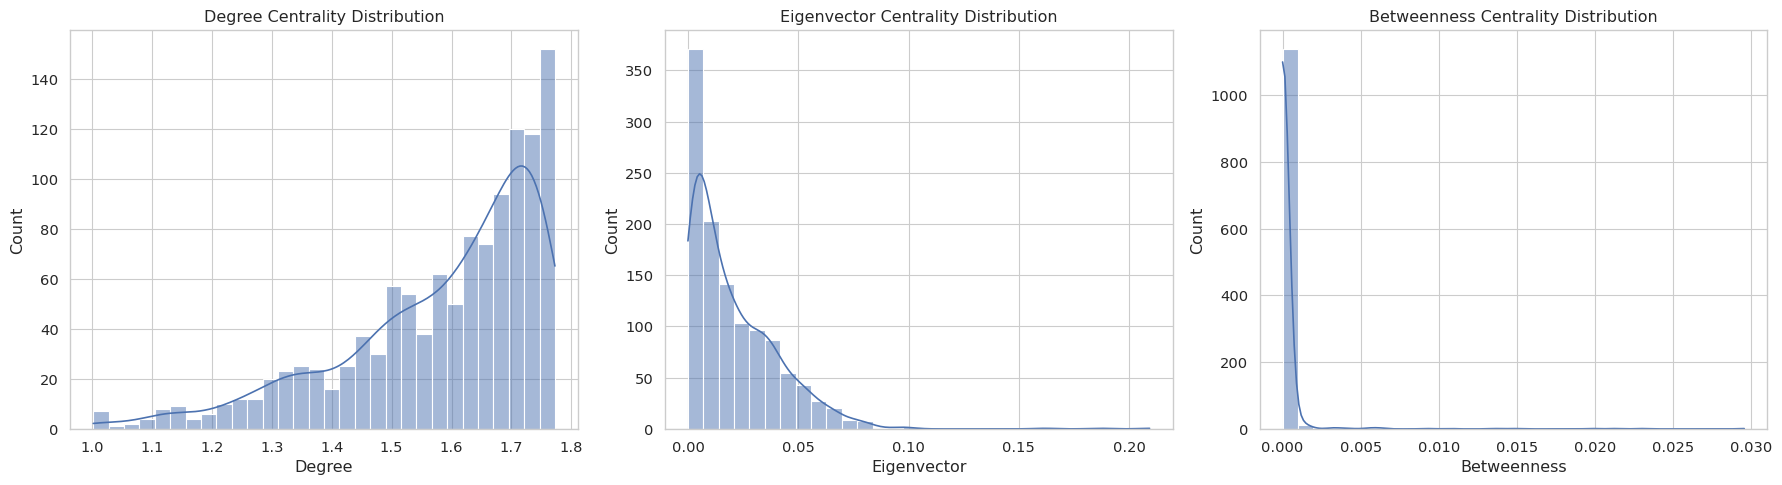

In [24]:
# Using a selected snapshot of the training data
snapshot = 10
G = nx.from_numpy_array(train_adjs[snapshot], create_using=nx.DiGraph)

degree_centrality = nx.degree_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G, weight='weight')
betweenness_centrality = nx.betweenness_centrality(G, weight='weight')

centrality_df = pd.DataFrame({
    'Degree': degree_centrality,
    'Eigenvector': eigenvector_centrality,
    'Betweenness': betweenness_centrality
})

print("--- Top 5 Nodes by Centrality Measures ---")
for col in centrality_df.columns:
    print(f"\n--- Top 5 by {col} Centrality ---")
    top_nodes = centrality_df[col].nlargest(5)
    top_nodes.index = [train_analyzer.index_to_stock[i] for i in top_nodes.index]
    display(top_nodes)

# --- Plotting Centrality Distributions ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(centrality_df.columns):
    sns.histplot(centrality_df[col], ax=axes[i], kde=True, bins=30)
    axes[i].set_title(f'{col} Centrality Distribution')
plt.tight_layout()
save_figure('centrality_distributions')
plt.show()

### 3.6. Subgraph Visualization with Target Labels

To better understand the relationship between graph structure and stock movements, we visualize a subgraph containing the most central nodes. Nodes are color-coded by their target prediction label: **green** indicates an upward price movement (target = 1), while **red** indicates a downward movement (target = 0).

This visualization helps us identify patterns such as:
- Whether highly central stocks tend to move together
- The presence of homophilous or heterophilous connections
- Local clustering of stocks with similar price movements

Figure saved to thesis_figures/subgraph_target_visualization_snapshot_10.pdf


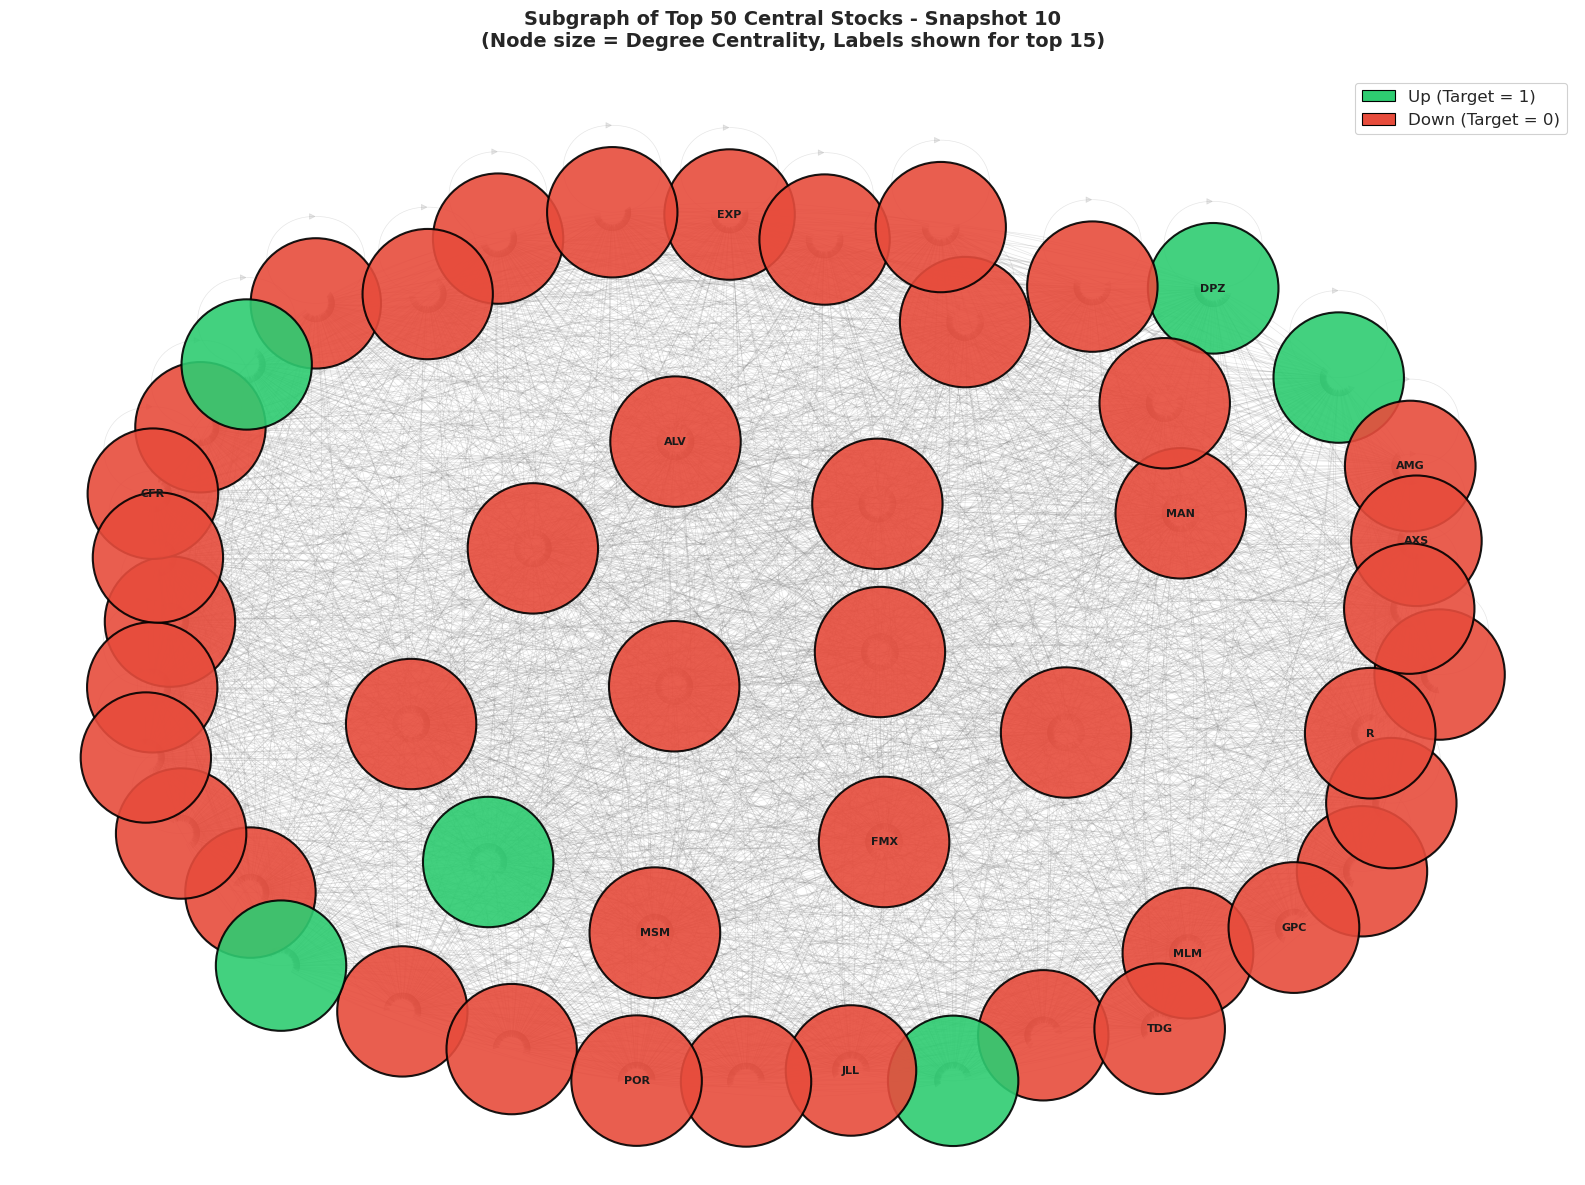


Subgraph Statistics (Snapshot 10):
Total nodes in subgraph: 50
Total edges in subgraph: 2500
Up stocks (green): 6 (12.0%)
Down stocks (red): 44 (88.0%)
Average clustering coefficient: 1.0000
Graph density: 1.0204



In [25]:
# Select a snapshot for visualization
SNAPSHOT_IDX = 10
TOP_N_NODES = 50  # Number of most central nodes to visualize

# Get adjacency matrix and create graph
adj = train_adjs[SNAPSHOT_IDX]
G_full = nx.from_numpy_array(adj, create_using=nx.DiGraph)

# Get target labels for this snapshot
snapshot_data = train_analyzer.graph_snapshots[SNAPSHOT_IDX]
targets = snapshot_data.y.numpy()

# Calculate degree centrality to select top nodes
degree_cent = nx.degree_centrality(G_full)
top_nodes = sorted(degree_cent, key=degree_cent.get, reverse=True)[:TOP_N_NODES]

# Create subgraph with only top central nodes
G_sub = G_full.subgraph(top_nodes).copy()

# Map node colors based on target (Up=Green, Down=Red)
node_colors = ['#2ecc71' if targets[node] == 1 else '#e74c3c' for node in G_sub.nodes()]
node_labels = {node: train_analyzer.index_to_stock[node] for node in G_sub.nodes()}

# Calculate node sizes based on centrality
node_sizes = [degree_cent[node] * 5000 for node in G_sub.nodes()]

# Create the visualization
plt.figure(figsize=(16, 12))

# Use spring layout for better visualization
pos = nx.spring_layout(G_sub, k=2, iterations=50, seed=42)

# Draw the graph
nx.draw_networkx_edges(G_sub, pos, alpha=0.2, edge_color='gray', 
                       arrows=True, arrowsize=10, width=0.5,
                       connectionstyle='arc3,rad=0.1')

nx.draw_networkx_nodes(G_sub, pos, 
                       node_color=node_colors,
                       node_size=node_sizes,
                       alpha=0.9,
                       edgecolors='black',
                       linewidths=1.5)

# Add labels for top 15 nodes
top_15_nodes = top_nodes[:15]
labels_subset = {node: node_labels[node] for node in top_15_nodes if node in G_sub.nodes()}
nx.draw_networkx_labels(G_sub, pos, labels_subset, font_size=8, font_weight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', edgecolor='black', label='Up (Target = 1)'),
    Patch(facecolor='#e74c3c', edgecolor='black', label='Down (Target = 0)')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12, framealpha=0.9)

plt.title(f'Subgraph of Top {TOP_N_NODES} Central Stocks - Snapshot {SNAPSHOT_IDX}\n'
          f'(Node size = Degree Centrality, Labels shown for top 15)', 
          fontsize=14, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
save_figure(f'subgraph_target_visualization_snapshot_{SNAPSHOT_IDX}')
plt.show()

# Print statistics
up_count = sum(1 for node in G_sub.nodes() if targets[node] == 1)
down_count = len(G_sub.nodes()) - up_count
print(f"\n{'='*60}")
print(f"Subgraph Statistics (Snapshot {SNAPSHOT_IDX}):")
print(f"{'='*60}")
print(f"Total nodes in subgraph: {len(G_sub.nodes())}")
print(f"Total edges in subgraph: {len(G_sub.edges())}")
print(f"Up stocks (green): {up_count} ({up_count/len(G_sub.nodes())*100:.1f}%)")
print(f"Down stocks (red): {down_count} ({down_count/len(G_sub.nodes())*100:.1f}%)")
print(f"Average clustering coefficient: {nx.average_clustering(G_sub):.4f}")
print(f"Graph density: {nx.density(G_sub):.4f}")
print(f"{'='*60}\n")

Figure saved to thesis_figures/subgraph_circular_layout_snapshot_10.pdf


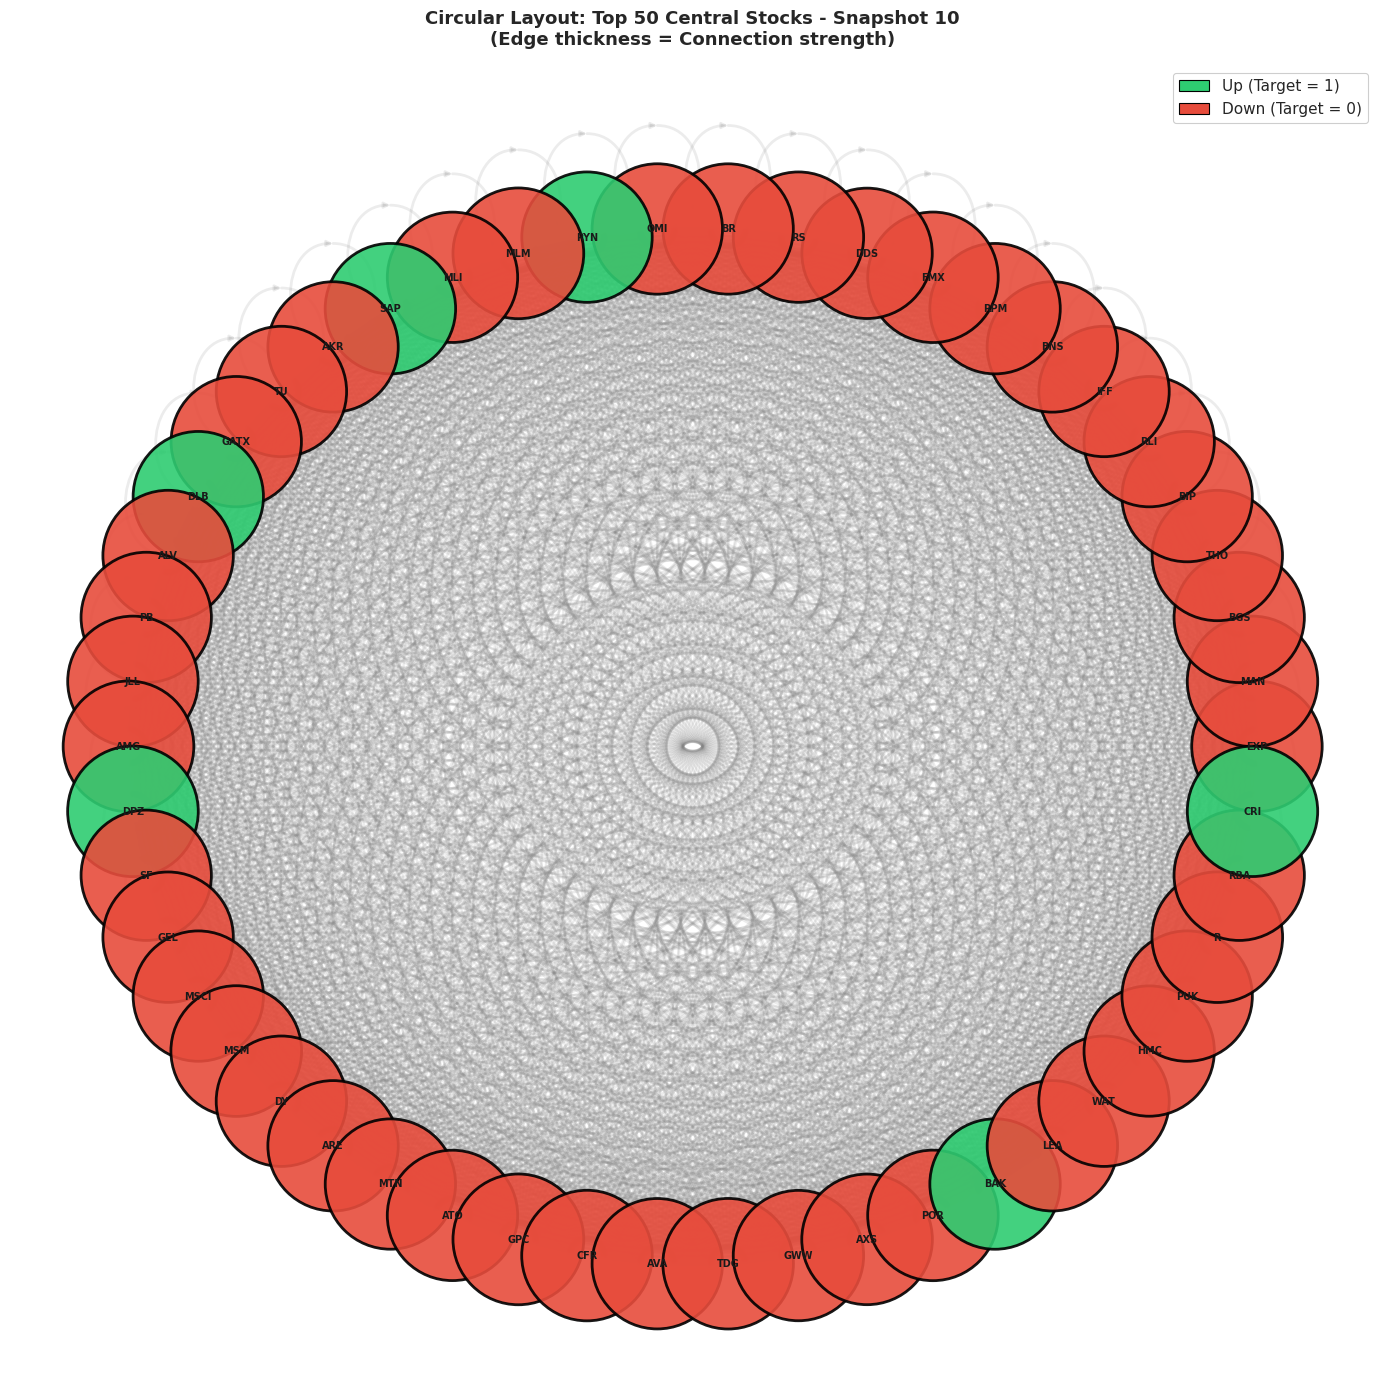

In [26]:
# Alternative visualization: Circular layout for better symmetry
plt.figure(figsize=(14, 14))

# Use circular layout
pos_circular = nx.circular_layout(G_sub)

# Draw edges with varying thickness based on weight
edges = G_sub.edges()
weights = [G_sub[u][v].get('weight', 1) for u, v in edges]
max_weight = max(weights) if weights else 1
edge_widths = [w / max_weight * 2 for w in weights]

nx.draw_networkx_edges(G_sub, pos_circular, 
                       alpha=0.15, 
                       edge_color='gray',
                       width=edge_widths,
                       arrows=True, 
                       arrowsize=8,
                       connectionstyle='arc3,rad=0.05')

nx.draw_networkx_nodes(G_sub, pos_circular,
                       node_color=node_colors,
                       node_size=node_sizes,
                       alpha=0.9,
                       edgecolors='black',
                       linewidths=2)

# Add all labels in circular layout for better readability
nx.draw_networkx_labels(G_sub, pos_circular, node_labels, 
                       font_size=7, font_weight='bold')

# Legend
plt.legend(handles=legend_elements, loc='upper right', fontsize=11, framealpha=0.95)

plt.title(f'Circular Layout: Top {TOP_N_NODES} Central Stocks - Snapshot {SNAPSHOT_IDX}\n'
          f'(Edge thickness = Connection strength)', 
          fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
save_figure(f'subgraph_circular_layout_snapshot_{SNAPSHOT_IDX}')
plt.show()

Figure saved to thesis_figures/subgraph_homophily_analysis_snapshot_10.pdf


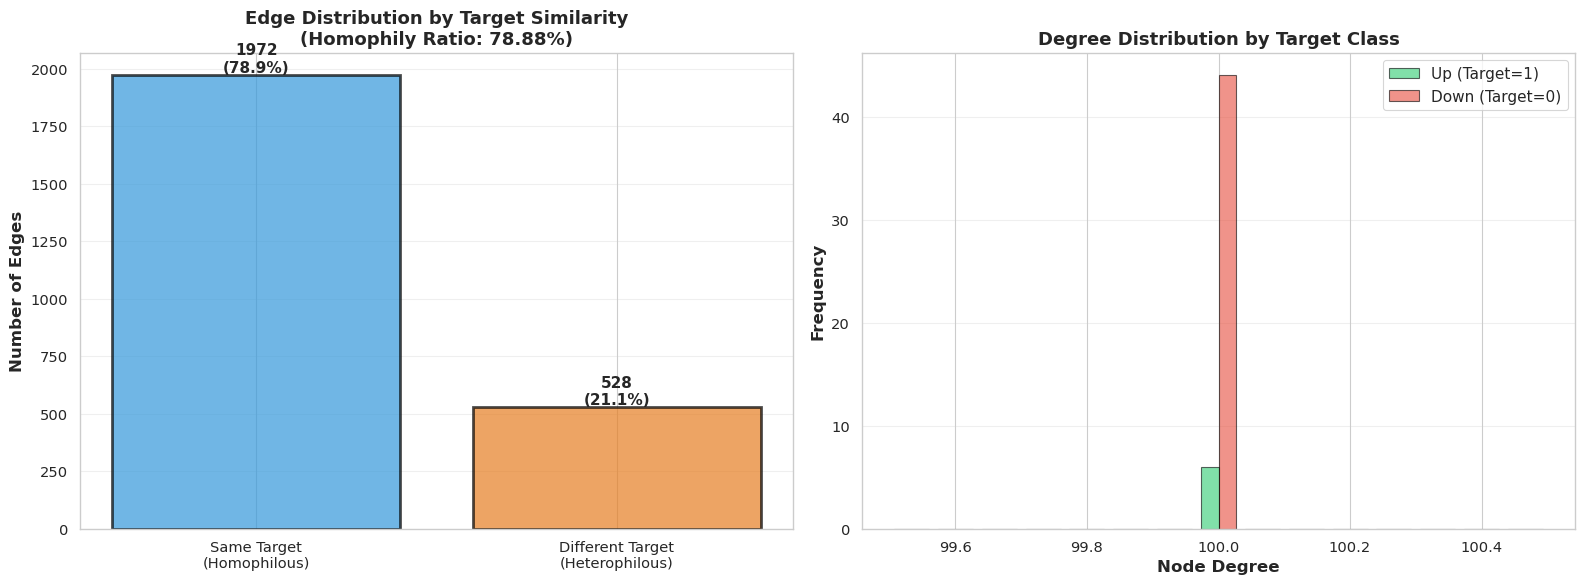


Homophily Analysis for Subgraph:
Same-target edges (homophilous): 1972 (78.88%)
Different-target edges (heterophilous): 528 (21.12%)

Average degree of Up stocks: 100.00 ± 0.00
Average degree of Down stocks: 100.00 ± 0.00



In [27]:
# Analyze homophily in the subgraph
# Count edges between same-target nodes vs different-target nodes
same_target_edges = 0
diff_target_edges = 0

for u, v in G_sub.edges():
    if targets[u] == targets[v]:
        same_target_edges += 1
    else:
        diff_target_edges += 1

total_edges = same_target_edges + diff_target_edges
homophily_ratio = same_target_edges / total_edges if total_edges > 0 else 0

# Visualize homophily patterns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Homophily ratio
ax1 = axes[0]
categories = ['Same Target\n(Homophilous)', 'Different Target\n(Heterophilous)']
counts = [same_target_edges, diff_target_edges]
colors_bar = ['#3498db', '#e67e22']

bars = ax1.bar(categories, counts, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Number of Edges', fontsize=12, fontweight='bold')
ax1.set_title(f'Edge Distribution by Target Similarity\n(Homophily Ratio: {homophily_ratio:.2%})', 
              fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({count/total_edges*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Right plot: Degree distribution by target class
ax2 = axes[1]
up_degrees = [G_sub.degree(node) for node in G_sub.nodes() if targets[node] == 1]
down_degrees = [G_sub.degree(node) for node in G_sub.nodes() if targets[node] == 0]

ax2.hist([up_degrees, down_degrees], bins=15, label=['Up (Target=1)', 'Down (Target=0)'],
         color=['#2ecc71', '#e74c3c'], alpha=0.6, edgecolor='black')
ax2.set_xlabel('Node Degree', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Degree Distribution by Target Class', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_figure(f'subgraph_homophily_analysis_snapshot_{SNAPSHOT_IDX}')
plt.show()

print(f"\n{'='*60}")
print(f"Homophily Analysis for Subgraph:")
print(f"{'='*60}")
print(f"Same-target edges (homophilous): {same_target_edges} ({homophily_ratio:.2%})")
print(f"Different-target edges (heterophilous): {diff_target_edges} ({(1-homophily_ratio):.2%})")
print(f"\nAverage degree of Up stocks: {np.mean(up_degrees):.2f} ± {np.std(up_degrees):.2f}")
print(f"Average degree of Down stocks: {np.mean(down_degrees):.2f} ± {np.std(down_degrees):.2f}")
print(f"{'='*60}\n")

### 3.5. Hub and Authority Analysis

In a directed graph, we can identify influential nodes by their degrees.
-   **Authorities** are nodes with high in-degree. They are pointed to by many other nodes and can be considered as important information sinks or bellwethers.
-   **Hubs** are nodes with high out-degree. They point to many other nodes and act as information sources or spreaders.

This analysis helps identify which stocks are central to the market network and which are on the periphery. We calculate the average degrees for each node across all snapshots in the training set to get a stable measure of their importance.


## For Train

--- Top 10 Authorities (Highest In-Degree) ---


,ticker,avg_in_degree,avg_weighted_in_degree
1012,TCAP,1170.630137,813.601196
555,JBR,1169.630137,719.108948
885,PYS,1169.479452,650.147339
195,CBI,1168.894977,604.992065
474,GYC,1167.598174,454.627319
760,NOM,1167.566210,434.128296
49,ALX,1167.242009,384.384338
132,BH,1167.210046,384.906219
415,FMY,1167.146119,374.077850
787,NXN,1167.050228,381.069458



--- Top 10 Hubs (Highest Out-Degree) ---


,ticker,avg_out_degree,avg_weighted_out_degree
549,ITUB,1171.0,391.372070
1133,WFC,1171.0,377.892792
1009,T,1171.0,392.291962
184,C,1171.0,365.959717
228,CMG,1171.0,435.991852
1143,WMT,1171.0,389.436584
835,PFE,1171.0,382.828094
386,F,1171.0,409.276642
98,BAC,1171.0,471.437439
899,RF,1171.0,364.385101



--- Top 10 Marginal Stocks (Lowest Total Degree) ---


,ticker,total_degree
1012,TCAP,1172.000000
555,JBR,1172.849315
885,PYS,1172.849315
98,BAC,1191.022831
474,GYC,1196.648402
195,CBI,1197.447489
760,NOM,1201.054795
228,CMG,1223.351598
386,F,1255.013699
1009,T,1296.520548


Figure saved to thesis_figures/hubs_vs_authorities_train.pdf


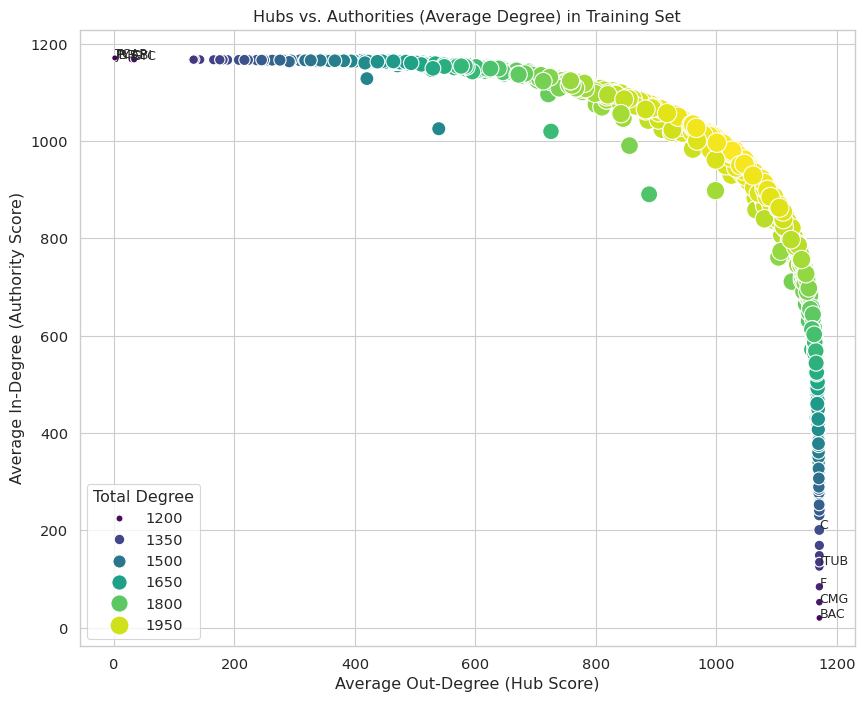

In [28]:
# --- Calculate average degrees across all snapshots for the training set ---
avg_degree_df = train_analyzer.get_average_node_degrees()

# --- Identify Top 10 Authorities (Highest In-Degree) ---
top_authorities = avg_degree_df.sort_values(by='avg_in_degree', ascending=False).head(10)
print("--- Top 10 Authorities (Highest In-Degree) ---")
display(top_authorities[['ticker', 'avg_in_degree', 'avg_weighted_in_degree']])

# --- Identify Top 10 Hubs (Highest Out-Degree) ---
top_hubs = avg_degree_df.sort_values(by='avg_out_degree', ascending=False).head(10)
print("\n--- Top 10 Hubs (Highest Out-Degree) ---")
display(top_hubs[['ticker', 'avg_out_degree', 'avg_weighted_out_degree']])

# --- Identify Marginal Stocks (Lowest Total Degree) ---
avg_degree_df['total_degree'] = avg_degree_df['avg_in_degree'] + avg_degree_df['avg_out_degree']
marginal_stocks = avg_degree_df.sort_values(by='total_degree', ascending=True).head(10)
print("\n--- Top 10 Marginal Stocks (Lowest Total Degree) ---")
display(marginal_stocks[['ticker', 'total_degree']])

# --- Visualize Hubs vs Authorities ---
plt.figure(figsize=(10, 8))
sns.scatterplot(data=avg_degree_df, x='avg_out_degree', y='avg_in_degree', 
                size='total_degree', hue='total_degree', palette='viridis', sizes=(20, 200))

# Annotate top 5 hubs and authorities
for i, row in avg_degree_df.nlargest(5, 'avg_in_degree').iterrows():
    plt.text(row['avg_out_degree'], row['avg_in_degree'], row['ticker'], fontsize=9, ha='left')
for i, row in avg_degree_df.nlargest(5, 'avg_out_degree').iterrows():
    plt.text(row['avg_out_degree'], row['avg_in_degree'], row['ticker'], fontsize=9, ha='left')

plt.title('Hubs vs. Authorities (Average Degree) in Training Set')
plt.xlabel('Average Out-Degree (Hub Score)')
plt.ylabel('Average In-Degree (Authority Score)')
plt.legend(title='Total Degree')
save_figure('hubs_vs_authorities_train')
plt.show()


Figure saved to thesis_figures/hubs_vs_authorities_weighted_train.pdf


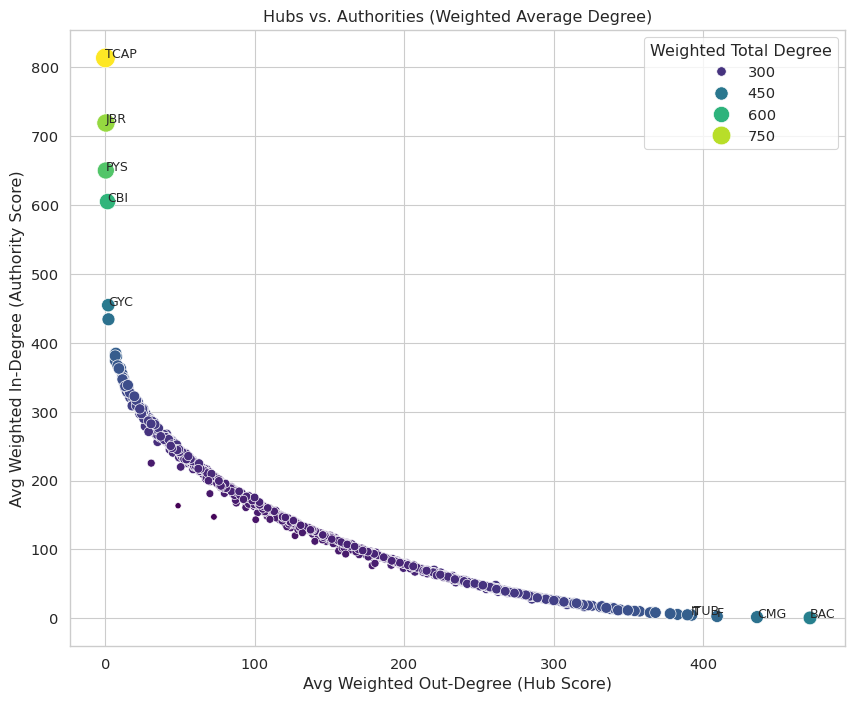

In [29]:
# --- Visualize Hubs vs Authorities (Weighted Degrees) ---
# Create a weighted total degree for sizing/coloring
avg_degree_df['weighted_total_degree'] = avg_degree_df['avg_weighted_in_degree'] + avg_degree_df['avg_weighted_out_degree']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=avg_degree_df,
    x='avg_weighted_out_degree',
    y='avg_weighted_in_degree',
    size='weighted_total_degree',
    hue='weighted_total_degree',
    palette='viridis',
    sizes=(20, 200)
)

# Annotate top 5 weighted authorities and hubs
for _, row in avg_degree_df.nlargest(5, 'avg_weighted_in_degree').iterrows():
    plt.text(row['avg_weighted_out_degree'], row['avg_weighted_in_degree'], row['ticker'], fontsize=9, ha='left')
for _, row in avg_degree_df.nlargest(5, 'avg_weighted_out_degree').iterrows():
    plt.text(row['avg_weighted_out_degree'], row['avg_weighted_in_degree'], row['ticker'], fontsize=9, ha='left')

plt.title('Hubs vs. Authorities (Weighted Average Degree)')
plt.xlabel('Avg Weighted Out-Degree (Hub Score)')
plt.ylabel('Avg Weighted In-Degree (Authority Score)')
plt.legend(title='Weighted Total Degree')
save_figure('hubs_vs_authorities_weighted_train')
plt.show()

## For Test

--- Top 10 Authorities (Highest In-Degree) ---


,ticker,avg_in_degree,avg_weighted_in_degree
1012,TCAP,1171.000000,818.587097
555,JBR,1169.953092,698.498352
474,GYC,1167.912580,476.846283
885,PYS,1167.846482,444.207764
760,NOM,1167.660981,414.192688
585,KF,1167.321962,383.657837
787,NXN,1167.307036,383.921448
710,MTR,1167.279318,384.972748
415,FMY,1167.140725,376.609955
204,CEE,1167.138593,373.275452



--- Top 10 Hubs (Highest Out-Degree) ---


,ticker,avg_out_degree,avg_weighted_out_degree
1133,WFC,1171.0,373.475555
184,C,1171.0,353.869781
1009,T,1171.0,421.869843
386,F,1171.0,415.082397
98,BAC,1171.0,441.567535
835,PFE,1171.0,381.909149
549,ITUB,1171.0,385.308533
1121,VZ,1171.0,349.063324
1143,WMT,1171.0,380.311127
228,CMG,1171.0,410.380554



--- Top 10 Marginal Stocks (Lowest Total Degree) ---


,ticker,total_degree
1012,TCAP,1172.000000
555,JBR,1172.955224
474,GYC,1178.166311
98,BAC,1213.897655
760,NOM,1224.955224
1009,T,1240.379531
386,F,1244.004264
228,CMG,1267.098081
885,PYS,1275.466951
508,HSEB,1287.134328


Figure saved to thesis_figures/hubs_vs_authorities_test.pdf


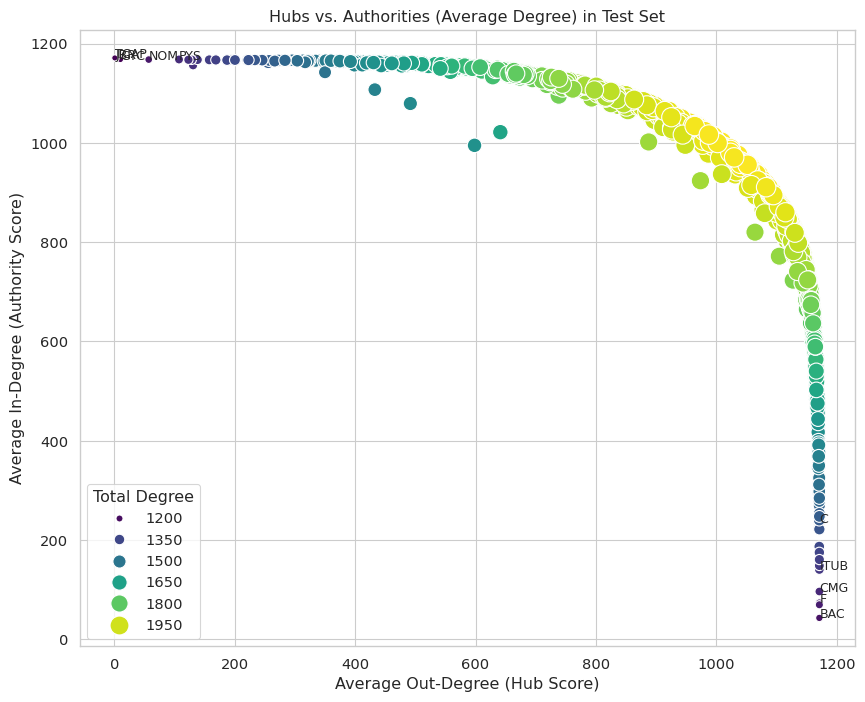

In [30]:
# --- Calculate average degrees across all snapshots for the test set ---
avg_degree_df = test_analyzer.get_average_node_degrees()

# --- Identify Top 10 Authorities (Highest In-Degree) ---
top_authorities = avg_degree_df.sort_values(by='avg_in_degree', ascending=False).head(10)
print("--- Top 10 Authorities (Highest In-Degree) ---")
display(top_authorities[['ticker', 'avg_in_degree', 'avg_weighted_in_degree']])

# --- Identify Top 10 Hubs (Highest Out-Degree) ---
top_hubs = avg_degree_df.sort_values(by='avg_out_degree', ascending=False).head(10)
print("\n--- Top 10 Hubs (Highest Out-Degree) ---")
display(top_hubs[['ticker', 'avg_out_degree', 'avg_weighted_out_degree']])

# --- Identify Marginal Stocks (Lowest Total Degree) ---
avg_degree_df['total_degree'] = avg_degree_df['avg_in_degree'] + avg_degree_df['avg_out_degree']
marginal_stocks = avg_degree_df.sort_values(by='total_degree', ascending=True).head(10)
print("\n--- Top 10 Marginal Stocks (Lowest Total Degree) ---")
display(marginal_stocks[['ticker', 'total_degree']])

# --- Visualize Hubs vs Authorities ---
plt.figure(figsize=(10, 8))
sns.scatterplot(data=avg_degree_df, x='avg_out_degree', y='avg_in_degree', 
                size='total_degree', hue='total_degree', palette='viridis', sizes=(20, 200))

# Annotate top 5 hubs and authorities
for i, row in avg_degree_df.nlargest(5, 'avg_in_degree').iterrows():
    plt.text(row['avg_out_degree'], row['avg_in_degree'], row['ticker'], fontsize=9, ha='left')
for i, row in avg_degree_df.nlargest(5, 'avg_out_degree').iterrows():
    plt.text(row['avg_out_degree'], row['avg_in_degree'], row['ticker'], fontsize=9, ha='left')

plt.title('Hubs vs. Authorities (Average Degree) in Test Set')
plt.xlabel('Average Out-Degree (Hub Score)')
plt.ylabel('Average In-Degree (Authority Score)')
plt.legend(title='Total Degree')
save_figure('hubs_vs_authorities_test')
plt.show()


Figure saved to thesis_figures/hubs_vs_authorities_weighted_test.pdf


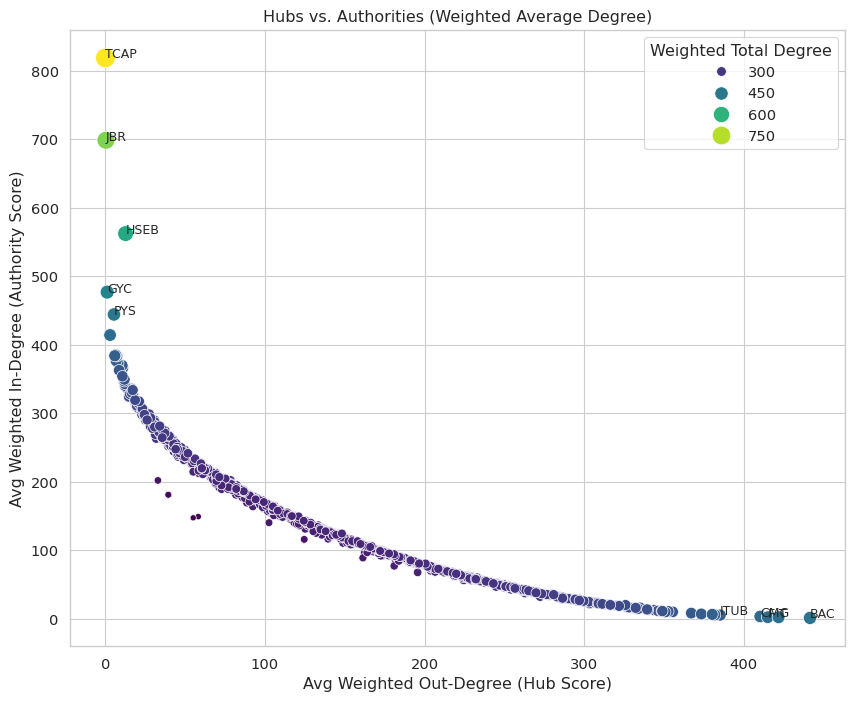

In [31]:
# --- Visualize Hubs vs Authorities (Weighted Degrees) ---
# Create a weighted total degree for sizing/coloring
avg_degree_df['weighted_total_degree'] = avg_degree_df['avg_weighted_in_degree'] + avg_degree_df['avg_weighted_out_degree']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=avg_degree_df,
    x='avg_weighted_out_degree',
    y='avg_weighted_in_degree',
    size='weighted_total_degree',
    hue='weighted_total_degree',
    palette='viridis',
    sizes=(20, 200)
)

# Annotate top 5 weighted authorities and hubs
for _, row in avg_degree_df.nlargest(5, 'avg_weighted_in_degree').iterrows():
    plt.text(row['avg_weighted_out_degree'], row['avg_weighted_in_degree'], row['ticker'], fontsize=9, ha='left')
for _, row in avg_degree_df.nlargest(5, 'avg_weighted_out_degree').iterrows():
    plt.text(row['avg_weighted_out_degree'], row['avg_weighted_in_degree'], row['ticker'], fontsize=9, ha='left')

plt.title('Hubs vs. Authorities (Weighted Average Degree)')
plt.xlabel('Avg Weighted Out-Degree (Hub Score)')
plt.ylabel('Avg Weighted In-Degree (Authority Score)')
plt.legend(title='Weighted Total Degree')
save_figure('hubs_vs_authorities_weighted_test')
plt.show()

### 3.5. Hub and Authority Analysis

In a directed graph, we can identify influential nodes by their degrees.
-   **Authorities** are nodes with high in-degree. They are pointed to by many other nodes and can be considered as important information sinks or bellwethers.
-   **Hubs** are nodes with high out-degree. They point to many other nodes and act as information sources or spreaders.

This analysis helps identify which stocks are central to the market network and which are on the periphery. We calculate the average degrees for each node across all snapshots in the training set to get a stable measure of their importance.


## 4. Temporal Analysis

Here, we analyze how graph properties evolve over time.

Figure saved to thesis_figures/temporal_adj_stability.pdf


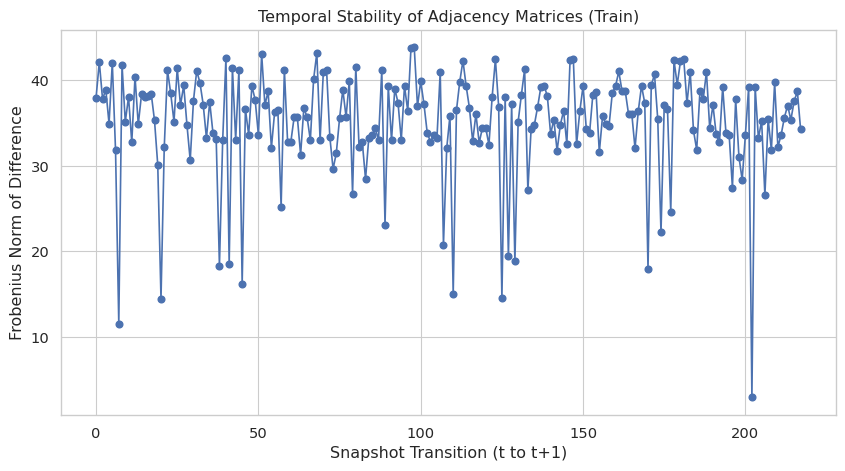

In [32]:
# --- Adjacency Matrix Stability ---
adj_diffs = []
for i in range(1, len(train_adjs)):
    diff = np.linalg.norm(train_adjs[i] - train_adjs[i-1], 'fro')
    adj_diffs.append(diff)

plt.figure(figsize=(10, 5))
plt.plot(adj_diffs, marker='o', linestyle='-')
plt.title('Temporal Stability of Adjacency Matrices (Train)')
plt.xlabel('Snapshot Transition (t to t+1)')
plt.ylabel('Frobenius Norm of Difference')
save_figure('temporal_adj_stability')
plt.show()

In [33]:
# 10 Max spikes in edge weights across snapshots in adj_diffs
max_spikes = []
for i in range(len(adj_diffs)):
    max_spike = np.max(np.abs(adj_diffs[i]))
    max_spikes.append(max_spike)
top_10_max_spikes = np.argsort(max_spikes)[-10:]
top_10_max_spikes

array([178, 146, 123, 147, 181,  40,  51,  68,  97,  98])

Figure saved to thesis_figures/adjacency_matrices_spike.pdf


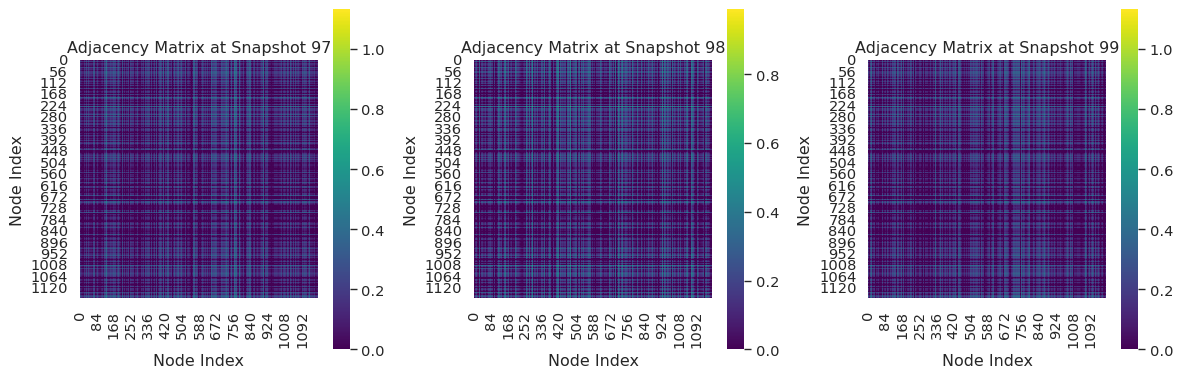

In [34]:
spike_idx = top_10_max_spikes[-1]  # Select the largest spike
plt.figure(figsize=(12, 4))  # or (12,4) if you want more spacing
plt.subplot(1, 3, 1)
sns.heatmap(train_adjs[spike_idx-1], cmap='viridis', square=True)
plt.title(f'Adjacency Matrix at Snapshot {spike_idx-1}')
plt.xlabel('Node Index')
plt.ylabel('Node Index')

plt.subplot(1, 3, 2)
sns.heatmap(train_adjs[spike_idx], cmap='viridis', square=True)
plt.title(f'Adjacency Matrix at Snapshot {spike_idx}')
plt.xlabel('Node Index')
plt.ylabel('Node Index')

plt.subplot(1, 3, 3)
sns.heatmap(train_adjs[spike_idx + 1], cmap='viridis', square=True)
plt.title(f'Adjacency Matrix at Snapshot {spike_idx + 1}')
plt.xlabel('Node Index')
plt.ylabel('Node Index')

plt.tight_layout()
save_figure('adjacency_matrices_spike')
plt.show()


Figure saved to thesis_figures/temporal_feature_trend.pdf


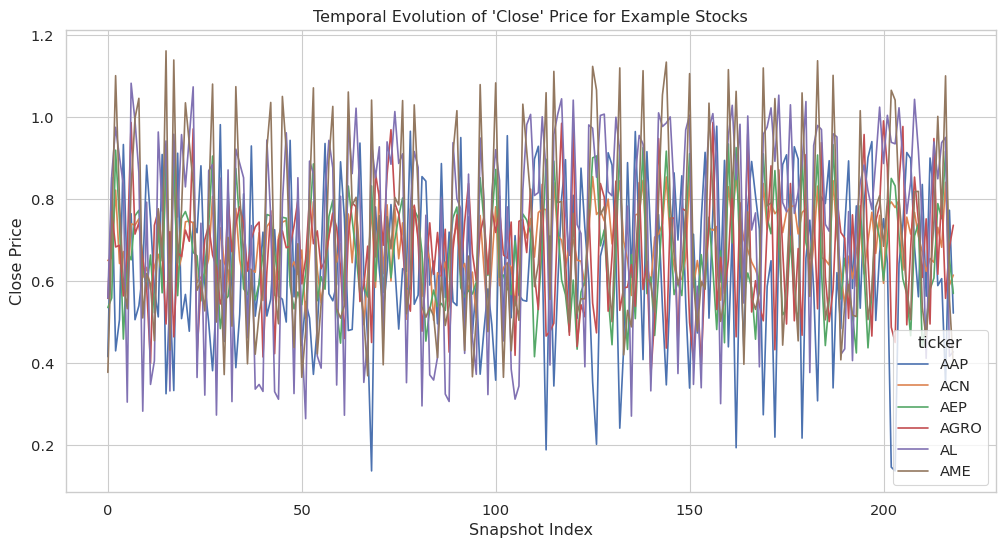

In [35]:
# --- Feature Trend Over Time ---
# Get 'Close' price time series for a few example stocks
example_stocks = [train_analyzer.index_to_stock[i] for i in [0, 10, 20, 30, 40, 50]]
ts_data = pd.DataFrame()
for stock in example_stocks:
    stock_ts = train_analyzer.get_feature_timeseries(stock_ticker=stock, feature='Close')
    ts_data = pd.concat([ts_data, stock_ts])

plt.figure(figsize=(12, 6))
sns.lineplot(data=ts_data, x='snapshot', y='value', hue='ticker')
plt.title('Temporal Evolution of \'Close\' Price for Example Stocks')
plt.xlabel('Snapshot Index')
plt.ylabel('Close Price')
save_figure('temporal_feature_trend')
plt.show()

## 5. Feature vs. Graph Analysis

This final analysis section investigates the interplay between node features and their structural roles in the graph.

Figure saved to thesis_figures/cross_dataset_homophily.pdf


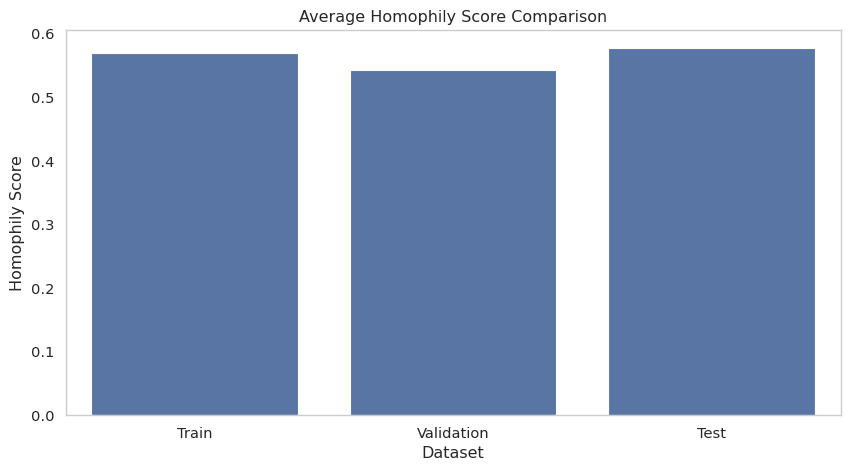

--- Average Homophily Scores ---


,Average Homophily
Train,0.569048
Validation,0.541961
Test,0.576767


In [36]:
# --- 5.1. Compare Average Homophily Across Datasets ---
homophily_scores = {name: analyzer.get_average_homophily_score() for name, analyzer in analyzers.items()}
homophily_df = pd.DataFrame.from_dict(homophily_scores, orient='index', columns=['Average Homophily'])

plt.figure(figsize=(10, 5))
sns.barplot(x=homophily_df.index, y=homophily_df['Average Homophily'])
plt.title('Average Homophily Score Comparison')
plt.ylabel('Homophily Score')
plt.xlabel('Dataset')
plt.grid(axis='y')
save_figure('cross_dataset_homophily')
plt.show()

print("--- Average Homophily Scores ---")
display(homophily_df)





Figure saved to thesis_figures/temporal_homophily_train.pdf


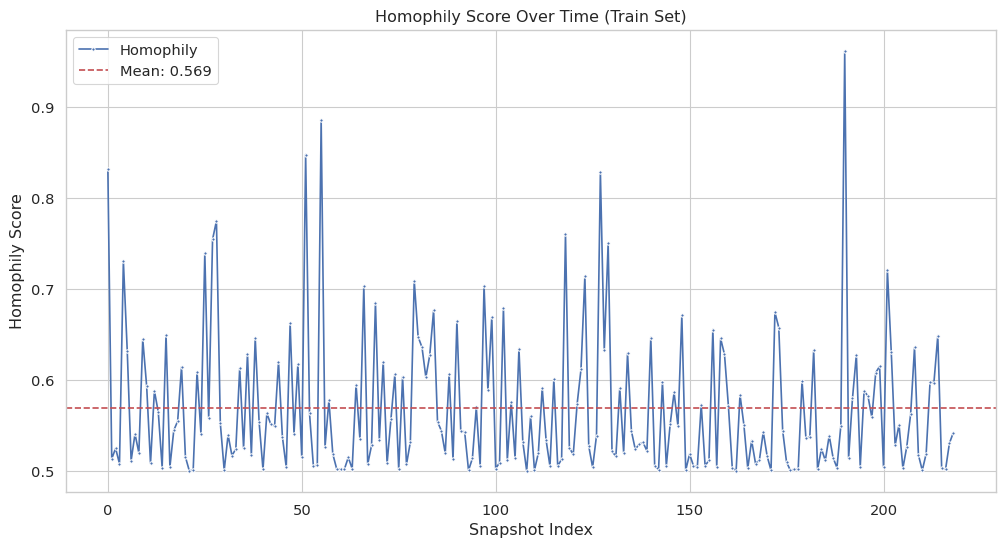

/tmp/ipykernel_3199212/2753398153.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Figure saved to thesis_figures/hist_homophily_train.pdf


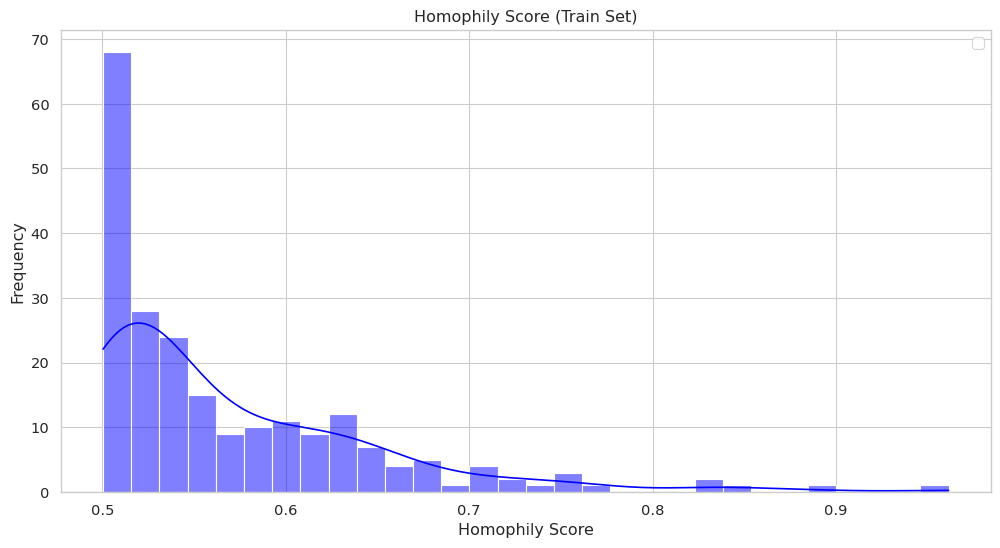

In [37]:
# --- 5.2. Homophily Score Over Time (Train Set) ---
# Motivation: To see if the level of homophily is stable or dynamic over time.
homophily_over_time = [train_analyzer.get_homophily_score(i) for i in range(train_analyzer.num_snapshots)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=homophily_over_time, marker='.', linestyle='-', label='Homophily')
plt.axhline(y=np.mean(homophily_over_time), color='r', linestyle='--', label=f'Mean: {np.mean(homophily_over_time):.3f}')
plt.title('Homophily Score Over Time (Train Set)')
plt.xlabel('Snapshot Index')
plt.ylabel('Homophily Score')
plt.legend()
save_figure('temporal_homophily_train')
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(homophily_over_time, bins=30, kde=True, color='blue', alpha=0.5)
plt.title('Homophily Score (Train Set)')
plt.xlabel('Homophily Score')
plt.ylabel('Frequency')
plt.legend()
save_figure('hist_homophily_train')
plt.show()

## 5. Homophily and Heterophily Analysis

**Motivation**: Homophily is the principle that similar nodes tend to connect with each other. In our context, it measures whether stocks that go "Up" tend to be connected to other "Up" stocks (and vice-versa). A high homophily score (closer to 1) suggests that neighbor information is strongly indicative of a node's own class, which is a favorable condition for GNNs. A low score (closer to 0) indicates heterophily, where connections are more common between nodes of different classes, presenting a greater challenge for standard GNN models.


### Graph Hyperbolicity Overview
We now quantify each snapshot's Gromov $\delta$-hyperbolicity (approximated via sampled 4-tuples) to assess how tree-like the market interaction graphs become across train/validation/test splits.

In [38]:
# Sample up to 500 quadruples per snapshot to keep runtime manageable.
SAMPLE_SIZE = 5
RANDOM_STATE = 42
hyperbolicity_summary = []
hyperbolicity_by_snapshot = []

for split_name, split_analyzer in analyzers.items():
    snapshot_scores = [
        split_analyzer.compute_snapshot_hyperbolicity(idx, sample_size=SAMPLE_SIZE, random_state=RANDOM_STATE)
        for idx in range(split_analyzer.num_snapshots)
    ]
    if not snapshot_scores:
        continue
    hyperbolicity_summary.append({
        "split": split_name,
        "avg_delta": float(np.mean(snapshot_scores)),
        "std_delta": float(np.std(snapshot_scores)),
        "max_delta": float(np.max(snapshot_scores)),
        "min_delta": float(np.min(snapshot_scores))
    })
    hyperbolicity_by_snapshot.append(pd.DataFrame({
        "split": split_name,
        "snapshot_index": range(len(snapshot_scores)),
        "delta_hyperbolicity": snapshot_scores
    }))

hyperbolicity_summary_df = pd.DataFrame(hyperbolicity_summary).sort_values("avg_delta")
display(hyperbolicity_summary_df)

hyperbolicity_by_snapshot_df = pd.concat(hyperbolicity_by_snapshot, ignore_index=True) if hyperbolicity_by_snapshot else pd.DataFrame()
if not hyperbolicity_by_snapshot_df.empty:
    plt.figure(figsize=(10, 4))
    sns.lineplot(data=hyperbolicity_by_snapshot_df, x="snapshot_index", y="delta_hyperbolicity", hue="split", marker="o")
    plt.title("Delta-hyperbolicity by snapshot")
    plt.ylabel("delta")
    plt.xlabel("Snapshot index")
    plt.tight_layout()
    save_figure('hyperbolicity_across_datasets')
    plt.show()
else:
    print("No hyperbolicity values were computed.")

KeyboardInterrupt: 

# Checking feature distribution

In [ ]:
import torch
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/home/mbisoffi/tests/TemporalGNNReview/code/data/datasets/hist_prices/NASDAQ/NASDAQ_TSLA.csv', parse_dates=['Date'], index_col='Date')

<Axes: xlabel='Date'>

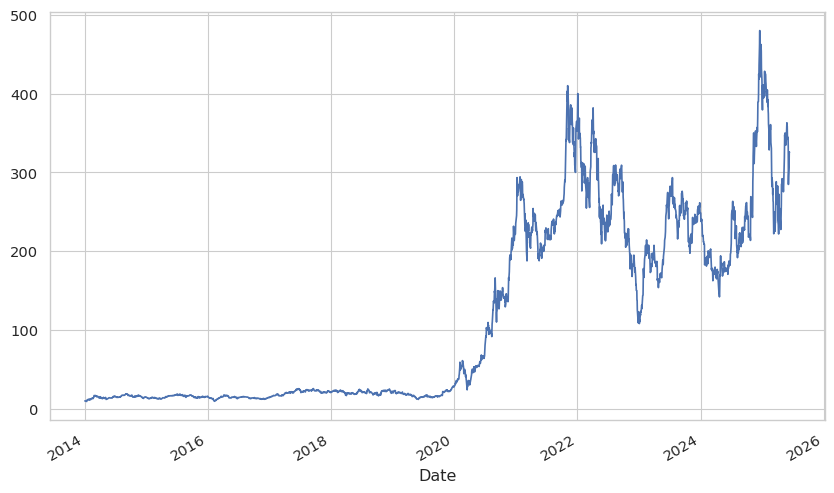

In [ ]:
df.Close.loc['2014':].plot()

<Axes: >

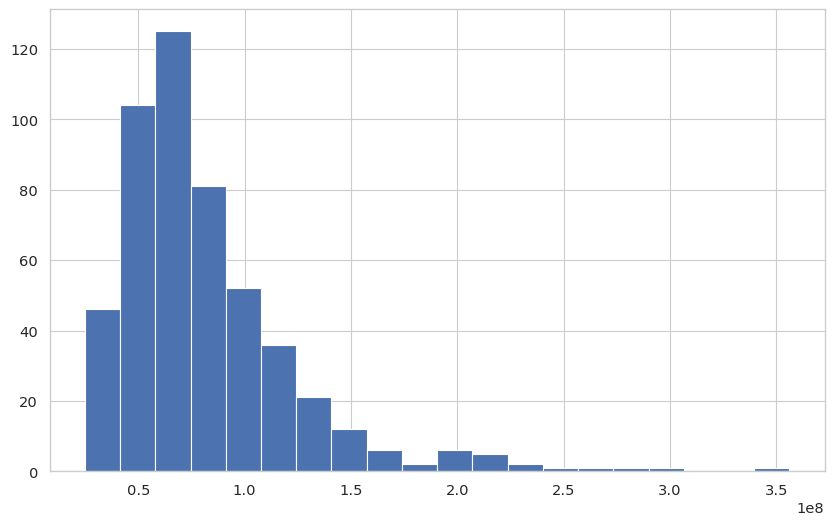

In [ ]:
df.Volume.loc['2016-01-01':'2018-01-01'].hist(bins=20)

<Axes: >

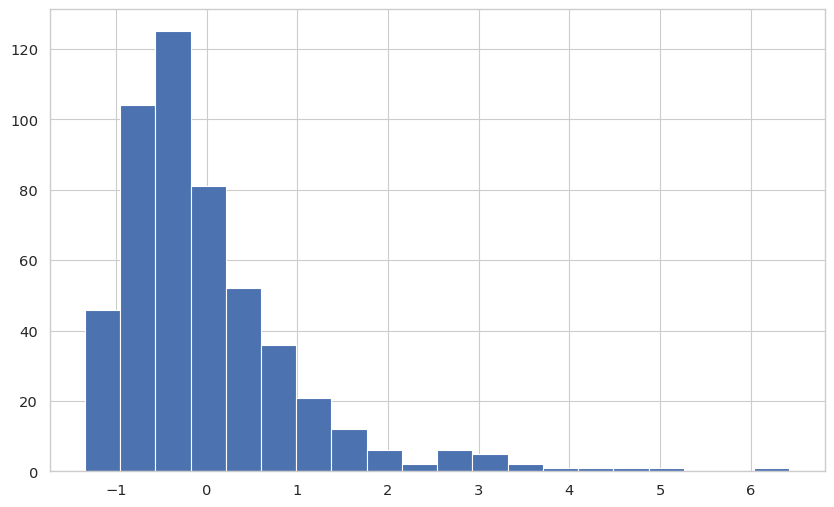

In [ ]:
# zscore normalization
( (df.Volume.loc['2016-01-01':'2018-01-01'] - df.Volume.loc['2016-01-01':'2018-01-01'].mean()) / df.Volume.loc['2016-01-01':'2018-01-01'].std()).hist(bins=20)

<Axes: >

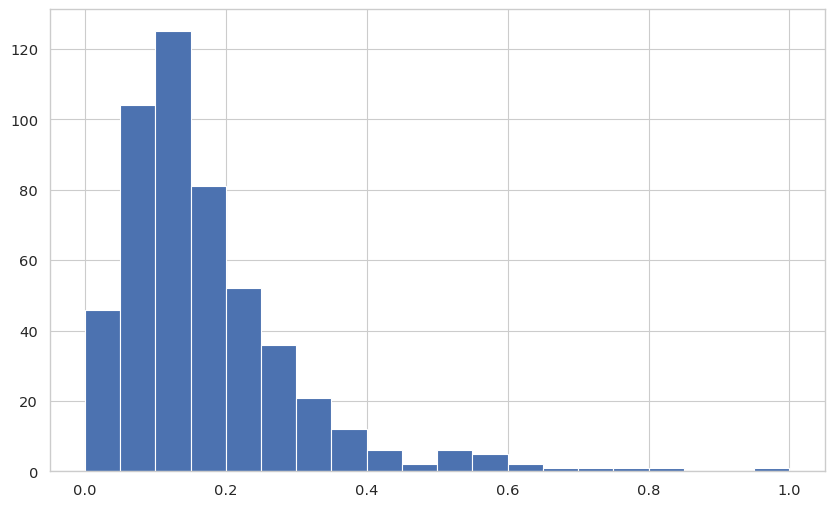

In [ ]:
# minmax normalization
((df.Volume.loc['2016-01-01':'2018-01-01'] - df.Volume.loc['2016-01-01':'2018-01-01'].min()) / (df.Volume.loc['2016-01-01':'2018-01-01'].max() - df.Volume.loc['2016-01-01':'2018-01-01'].min())).hist(bins=20) 

<Axes: >

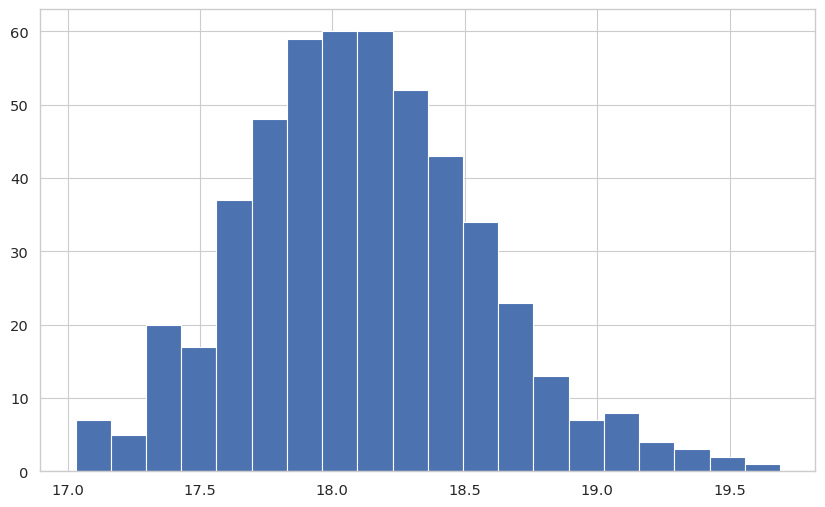

In [ ]:
# log1p normalization
np.log1p(df.Volume.loc['2016-01-01':'2018-01-01']).hist(bins=20)